# Procrustes Analysis and PCA

# sliding semilandmark

[*] 系統共抓取到 54 組檔案，準備處理...

[*] 處理完畢！成功提取了 54 個花瓣輪廓。


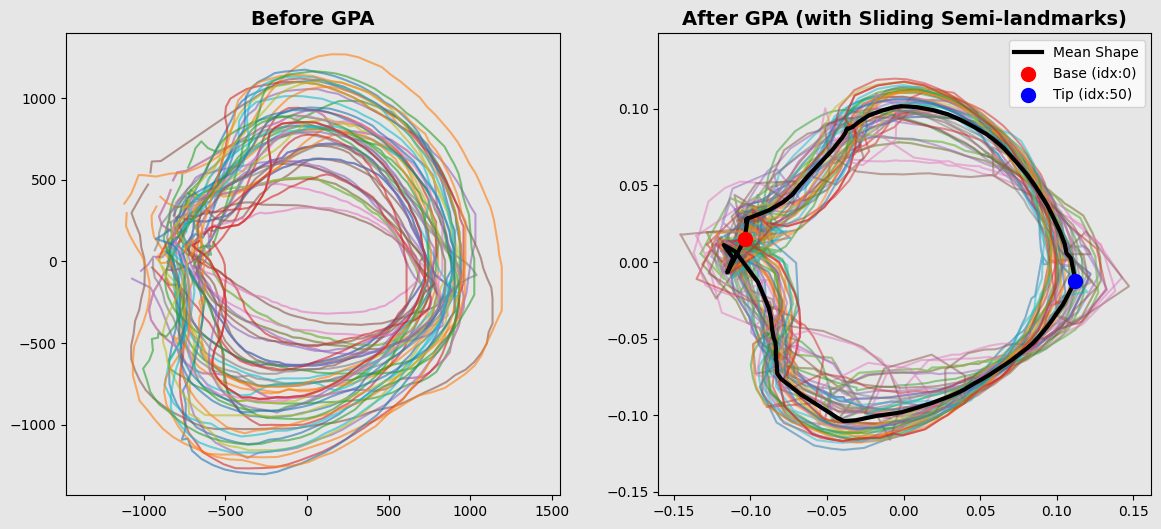


[*] 開始進行主成分分析 (PCA)...


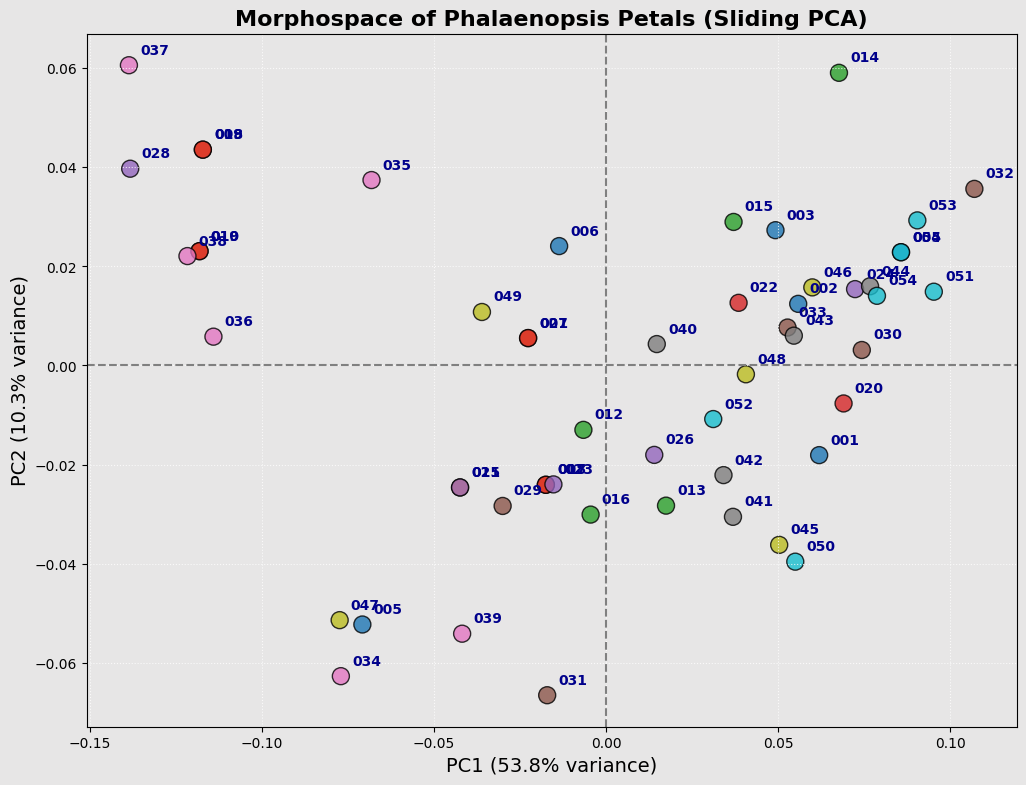

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as interp
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
import os
import glob

# ==========================================
# 1. 定義滑動半特徵點與 GPA 函數 🌟 (重大升級) 🌟
# ==========================================
def slide_points(shape, mean_shape, anchors=[0, 50], step_size=0.5):
    """
    計算切線並讓半特徵點沿著輪廓邊緣滑動，以最小化 Procrustes 距離
    """
    new_shape = np.copy(shape)
    N = len(shape)
    for i in range(N):
        if i in anchors:
            continue # 錨點 (基部與尖端) 絕對不准滑動！
            
        # 計算該點的局部切線向量 (利用前後兩個點)
        prev_idx = (i - 1) % N
        next_idx = (i + 1) % N
        tangent = shape[next_idx] - shape[prev_idx]
        norm = np.linalg.norm(tangent)
        
        if norm > 1e-6:
            tangent = tangent / norm # 單位切線向量
        else:
            continue
            
        # 計算該點到平均形狀目標點的向量
        vec_to_mean = mean_shape[i] - shape[i]
        
        # 將距離向量投影到切線上 (算出需要滑動的距離)
        slide_dist = np.dot(vec_to_mean, tangent)
        
        # 更新點的位置 (加入 step_size 避免滑動過頭導致點擠在一起)
        new_shape[i] = shape[i] + (step_size * slide_dist) * tangent
        
    return new_shape

def perform_gpa_with_sliding(shapes, max_iter=20, tol=1e-5):
    N, num_points, dims = shapes.shape
    
    # 初始縮放與置中
    centers = np.mean(shapes, axis=1, keepdims=True)
    centered_shapes = shapes - centers
    centroid_sizes = np.linalg.norm(centered_shapes, axis=(1, 2), keepdims=True)
    scaled_shapes = centered_shapes / centroid_sizes
    
    aligned_shapes = np.copy(scaled_shapes)
    mean_shape = aligned_shapes[0] 
    
    for iteration in range(max_iter):
        # 步驟 1: 旋轉對齊 (Procrustes)
        for i in range(N):
            R, _ = orthogonal_procrustes(aligned_shapes[i], mean_shape)
            aligned_shapes[i] = np.dot(aligned_shapes[i], R)
            
        # 步驟 2: 執行半特徵點滑動 (Sliding) 🌟
        if iteration > 0: # 第一次先對齊大方向，第二次才開始滑動
            for i in range(N):
                aligned_shapes[i] = slide_points(aligned_shapes[i], mean_shape, anchors=[0, 50])
                
        # 步驟 3: 重新計算平均形狀
        new_mean_shape = np.mean(aligned_shapes, axis=0)
        new_mean_shape /= np.linalg.norm(new_mean_shape)
        
        diff = np.linalg.norm(new_mean_shape - mean_shape)
        mean_shape = new_mean_shape
        if diff < tol:
            print(f"[*] GPA+Sliding 在第 {iteration+1} 次迭代收斂。")
            break
            
    return aligned_shapes, mean_shape

# ==========================================
# 2. 設定資料夾路徑與參數
# ==========================================
image_dir = './Datasets/test_dataset/images/'
mask_dir = './Datasets/test_dataset/masks/'

target_class_id = 7 
base_class_id = 1   
labellum_class_id = 3
num_landmarks = 100 
padding = 50

all_petals_landmarks = []
valid_filenames = []

# ==========================================
# 3. 批次處理影像 (Occlusion-Aware Anchored Split)
# ==========================================
def get_column_centroid(mask):
    mask_col = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M = cv2.moments(mask_col)
    if M['m00'] == 0: return None
    return np.array([int(M['m10'] / M['m00']), int(M['m01'] / M['m00'])])

def fix_occlusion(contour, mask):
    labellum = np.where(mask == labellum_class_id, 255, 0).astype(np.uint8)
    if cv2.countNonZero(labellum) == 0: return contour
    labellum_dilated = cv2.dilate(labellum, np.ones((11, 11), np.uint8), iterations=1)
    
    touching_idx = []
    for i in range(len(contour)):
        x, y = contour[i][0]
        if 0 <= y < labellum_dilated.shape[0] and 0 <= x < labellum_dilated.shape[1]:
            if labellum_dilated[y, x] > 0: touching_idx.append(i)
            
    if len(touching_idx) < 5: return contour
    
    touching_idx = np.array(touching_idx)
    diffs = np.diff(touching_idx)
    wrap_gap = len(contour) - touching_idx[-1] + touching_idx[0]
    all_gaps = np.append(diffs, wrap_gap)
    max_gap_idx = np.argmax(all_gaps)
    
    if max_gap_idx == len(diffs):
        occ_start, occ_end = touching_idx[0], touching_idx[-1]
    else:
        occ_start, occ_end = touching_idx[max_gap_idx + 1], touching_idx[max_gap_idx]
        
    pt_start, pt_end = contour[occ_start][0], contour[occ_end][0]
    
    if occ_start <= occ_end:
        valid_contour = np.concatenate([contour[occ_end:], contour[:occ_start+1]])
    else:
        valid_contour = contour[occ_end:occ_start+1]
        
    num_interp = 20
    xs, ys = np.linspace(pt_start[0], pt_end[0], num_interp), np.linspace(pt_start[1], pt_end[1], num_interp)
    patch_pts = np.column_stack((xs, ys)).reshape(-1, 1, 2).astype(np.int32)
    patch_pts = patch_pts[1:-1] if num_interp > 2 else np.empty((0, 1, 2), dtype=np.int32)
    return np.concatenate([valid_contour, patch_pts])

def resample_path(points, n_pts):
    if points is None or len(points) < 2:
        return None
    
    # 計算相鄰點的歐式距離
    diffs = np.diff(points, axis=0)
    dists = np.linalg.norm(diffs, axis=1)
    
    # 計算累積弧長 (Cumulative Arc Length)
    cum_dist = np.concatenate(([0], np.cumsum(dists)))
    total_dist = cum_dist[-1]
    
    if total_dist == 0:
        return np.tile(points[0], (n_pts, 1))
        
    # 等距採樣目標距離
    target_dist = np.linspace(0, total_dist, n_pts)
    
    # 對 x, y 分別做一維線性內插
    new_x = np.interp(target_dist, cum_dist, points[:, 0])
    new_y = np.interp(target_dist, cum_dist, points[:, 1])
    
    return np.column_stack([new_x, new_y])


image_paths = sorted([os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith('.png')])
print(f'[*] 系統共抓取到 {len(image_paths)} 組檔案，準備處理...')

for img_path in image_paths:
    filename = os.path.basename(img_path)
    stem = os.path.splitext(filename)[0]
    mask_path = os.path.join(mask_dir, f'{stem}.png')
    
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: continue

    mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
    
    col_centroid = get_column_centroid(mask)
    if col_centroid is None: continue

    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    mask_c7 = cv2.morphologyEx(mask_c7, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    cnts_c7, _ = cv2.findContours(mask_c7, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts_c7: continue

    # 只取面積最大的輪廓 (每張圖只有一個右花瓣)
    cnt = max(cnts_c7, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 100 or len(cnt) < 20: continue

    patched_cnt = fix_occlusion(cnt, mask)
        
    min_dist, base_idx = float('inf'), 0
    for idx, pt in enumerate(patched_cnt):
        dist = np.sum((pt[0].astype(float) - col_centroid)**2)
        if dist < min_dist: min_dist, base_idx = dist, idx
            
    base_pt = patched_cnt[base_idx][0].astype(float)
    max_dist, tip_idx = 0, 0
    for idx, pt in enumerate(patched_cnt):
        dist = np.sum((pt[0].astype(float) - base_pt)**2)
        if dist > max_dist: max_dist, tip_idx = dist, idx

    if base_idx == tip_idx: continue

    if base_idx < tip_idx:
        path1 = patched_cnt[base_idx : tip_idx+1][:, 0, :]
        path2 = np.concatenate([patched_cnt[tip_idx:], patched_cnt[:base_idx+1]])[:, 0, :]
    else:
        path1 = np.concatenate([patched_cnt[base_idx:], patched_cnt[:tip_idx+1]])[:, 0, :]
        path2 = patched_cnt[tip_idx : base_idx+1][:, 0, :]

    n_side = (num_landmarks // 2) + 1
    lm1, lm2 = resample_path(path1, n_side), resample_path(path2, n_side)
    if lm1 is None or lm2 is None: continue
        
    final_landmarks = np.concatenate([lm1[:-1], lm2[:-1]])
        
    all_petals_landmarks.append(final_landmarks)
    valid_filenames.append(stem)

# ==========================================
# 4. 執行 GPA (含 Sliding) 與 視覺化
# ==========================================
shapes_array = np.array(all_petals_landmarks)
print(f"\n[*] 處理完畢！成功提取了 {len(shapes_array)} 個花瓣輪廓。")
# --- 定義統一的底色 ---
bg_color = '#E7E6E6'
if len(shapes_array) > 1:
    aligned_shapes, mean_shape = perform_gpa_with_sliding(shapes_array) # 🌟 呼叫新函數
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor(bg_color) # 設定整張大畫布的底色
    
    axes[0].set_facecolor(bg_color)   # 設定左邊子圖的底色
    axes[0].set_title("Before GPA", fontsize=14, fontweight='bold')
    for i in range(len(shapes_array)):
        centered = shapes_array[i] - np.mean(shapes_array[i], axis=0)
        axes[0].plot(centered[:, 0], centered[:, 1], alpha=0.6, linewidth=1.5)
    axes[0].axis('equal')
    axes[1].set_facecolor(bg_color)   # 設定右邊子圖的底色
    axes[1].set_title("After GPA (with Sliding Semi-landmarks)", fontsize=14, fontweight='bold')
    for i in range(len(aligned_shapes)):
        closed_x = np.append(aligned_shapes[i, :, 0], aligned_shapes[i, 0, 0])
        closed_y = np.append(aligned_shapes[i, :, 1], aligned_shapes[i, 0, 1])
        axes[1].plot(closed_x, closed_y, alpha=0.5, linewidth=1.5)
    
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    axes[1].plot(mean_closed_x, mean_closed_y, color='black', linewidth=3, label='Mean Shape')
    axes[1].scatter(mean_shape[0, 0], mean_shape[0, 1], color='red', s=100, label='Base (idx:0)', zorder=5)
    axes[1].scatter(mean_shape[50, 0], mean_shape[50, 1], color='blue', s=100, label='Tip (idx:50)', zorder=5)
    axes[1].axis('equal')
    axes[1].legend()
    plt.show()
# ==========================================
# 5. 執行主成分分析 (PCA)
# ==========================================
    print("\n[*] 開始進行主成分分析 (PCA)...")
    N, num_points, dims = aligned_shapes.shape
    flattened_shapes = aligned_shapes.reshape(N, -1)
    pca = PCA(n_components=2)
    pcs = pca.fit_transform(flattened_shapes)
    explained_variance = pca.explained_variance_ratio_ * 100
    fig_pca, ax_pca = plt.subplots(figsize=(12, 9)) 
    fig_pca.patch.set_facecolor(bg_color) # 設定 PCA 大畫布的底色
    ax_pca.set_facecolor(bg_color)        # 設定 PCA 內部圖表的底色
    scatter = ax_pca.scatter(pcs[:, 0], pcs[:, 1], c=range(N), cmap='tab10', s=150, alpha=0.8, edgecolors='k')
    for i in range(N):
        ax_pca.annotate(valid_filenames[i], (pcs[i, 0], pcs[i, 1]), xytext=(8, 8), textcoords='offset points', fontsize=10, fontweight='bold', color='darkblue')
    ax_pca.set_title("Morphospace of Phalaenopsis Petals (Sliding PCA)", fontsize=16, fontweight='bold')
    ax_pca.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)", fontsize=14)
    ax_pca.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)", fontsize=14)
    ax_pca.axhline(0, color='gray', linestyle='--')
    ax_pca.axvline(0, color='gray', linestyle='--')
    
    # 這裡順便把格線 (Grid) 改成白色，在淺灰底上看起來會更清晰精緻
    plt.grid(True, linestyle=':', alpha=0.8, color='white')
    plt.show()


[*] 開始進行主成分分析 (PCA)...


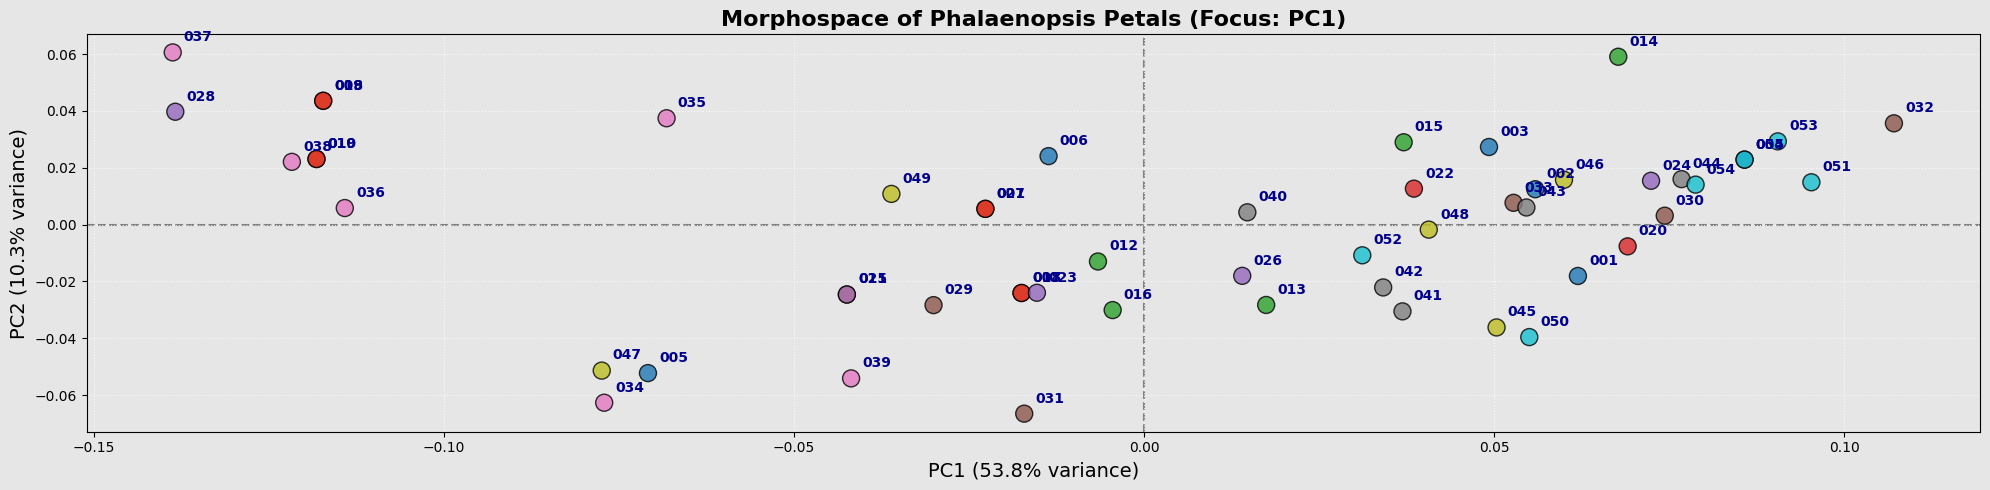

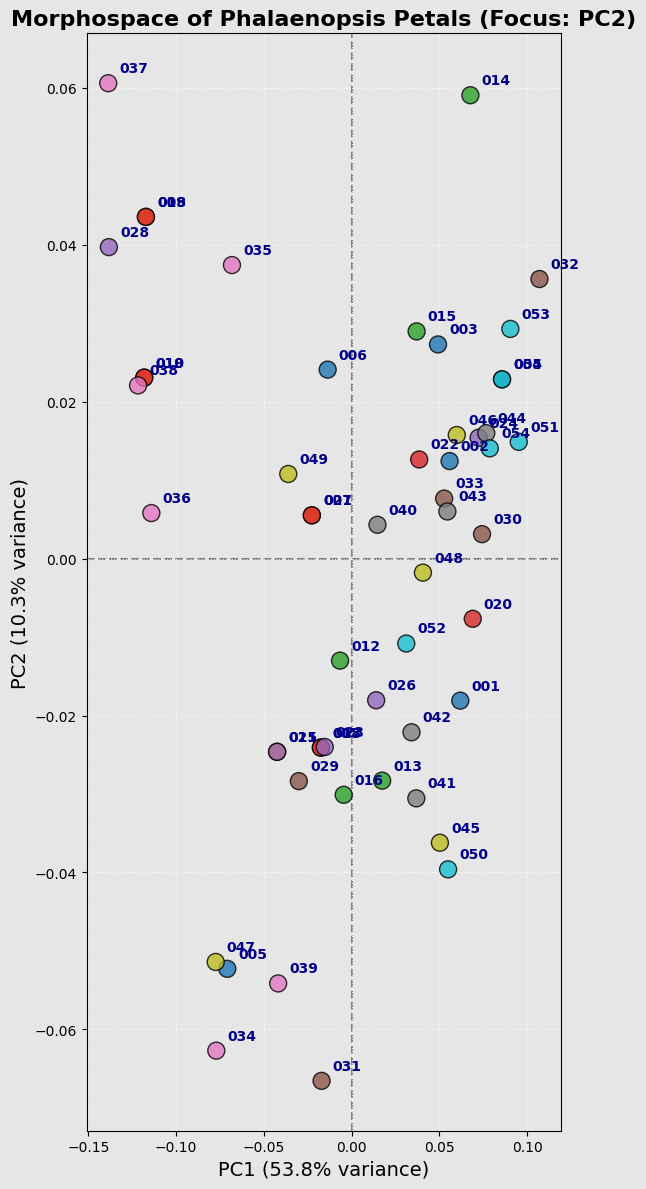

In [13]:
# ==========================================
# 5. 執行主成分分析 (PCA)
# ==========================================
print("\n[*] 開始進行主成分分析 (PCA)...")
N, num_points, dims = aligned_shapes.shape
flattened_shapes = aligned_shapes.reshape(N, -1)
pca = PCA(n_components=2)
pcs = pca.fit_transform(flattened_shapes)
explained_variance = pca.explained_variance_ratio_ * 100

def plot_pca_morphospace(pcs, valid_filenames, explained_variance, focus='PC1'):
    """
    動態調整 XY 軸比例的 PCA 繪圖函式 (專為簡報展示設計)
    focus: 'PC1' (拉長X軸), 'PC2' (拉長Y軸), 'Normal' (標準比例)
    """
    bg_color = '#E7E6E6'
    N = len(pcs)
    
    # 透過控制 figsize 來改變 XY 軸的視覺物理比例
    if focus == 'PC1':
        figsize = (20, 5)  # 極度拉長 X 軸 (PC1)，壓縮 Y 軸 (PC2)
    elif focus == 'PC2':
        figsize = (6, 12)  # 拉長 Y 軸 (PC2)，壓縮 X 軸 (PC1)
    else:
        figsize = (12, 9)  # 預設標準比例

    fig_pca, ax_pca = plt.subplots(figsize=figsize) 
    fig_pca.set_facecolor(bg_color)
    ax_pca.set_facecolor(bg_color)        

    # 繪製散佈圖 (加入 zorder 確保點與字在格線上方)
    ax_pca.scatter(pcs[:, 0], pcs[:, 1], c=range(N), cmap='tab10', s=150, alpha=0.8, edgecolors='k', zorder=3)
    
    # 標註檔名
    for i in range(N):
        ax_pca.annotate(valid_filenames[i], (pcs[i, 0], pcs[i, 1]), 
                        xytext=(8, 8), textcoords='offset points', 
                        fontsize=10, fontweight='bold', color='darkblue', zorder=4)
                        
    ax_pca.set_title(f"Morphospace of Phalaenopsis Petals (Focus: {focus})", fontsize=16, fontweight='bold')
    ax_pca.set_xlabel(f"PC1 ({explained_variance[0]:.1f}% variance)", fontsize=14)
    ax_pca.set_ylabel(f"PC2 ({explained_variance[1]:.1f}% variance)", fontsize=14)
    
    ax_pca.axhline(0, color='gray', linestyle='--', zorder=1)
    ax_pca.axvline(0, color='gray', linestyle='--', zorder=1)
    ax_pca.grid(True, linestyle=':', alpha=0.8, color='white', zorder=2)
    
    plt.tight_layout()
    plt.show()

# 呼叫方式：依照你的簡報需求切換 focus 參數
plot_pca_morphospace(pcs, valid_filenames, explained_variance, focus='PC1') # 展示 PC1 專用
plot_pca_morphospace(pcs, valid_filenames, explained_variance, focus='PC2') # 展示 PC2 專用
# plot_pca_morphospace(pcs, valid_filenames, explained_variance, focus='Normal') # 一般比例


In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 建立儲存視覺化結果的資料夾
output_dir = "./Datasets/Before_GPA_Landmarks_Viz"
os.makedirs(output_dir, exist_ok=True)

# === 自訂色彩與風格 ===
bg_color = '#E7E6E6'          # 指定的淺灰底色
bg_rgb = (231, 230, 230)      # 用於 OpenCV 影像底色填色的 RGB
point_color = '#1f4e79'       # 參考附圖的深藍色 Landmark
line_color = '#595959'        # 參考附圖的灰色輪廓線
padding = 50                  # 修正特徵提取時造成的 50 像素平移偏移

# 確保已經有定義好路徑 (依據你的 Notebook 設定)
# image_dir = './Datasets/test_dataset/images'
# mask_dir = './Datasets/test_dataset/masks'
# target_class_id = 7 

for i, (landmarks, name) in enumerate(zip(shapes_array, valid_filenames)):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100)
    fig.patch.set_facecolor(bg_color) 
    
    # ---------------------------------------------------------
    # 讀取對應的影像與遮罩
    # ---------------------------------------------------------
    # 若你的 valid_filenames 裡沒有 .png，請加上
    img_path = os.path.join(image_dir, f"{name}.png") 
    mask_path = os.path.join(mask_dir, f"{name}.png")
    
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img is not None and mask is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 加上 Padding 確保與 Landmark 座標系統完全一致 (修正偏移)
        img = cv2.copyMakeBorder(img, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=[0,0,0])
        mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
        
        # 🌟 將整張原圖的「非花朵區域 (mask == 0)」背景換成淺灰色 🌟
        img[mask == 0] = bg_rgb
    else:
        print(f"⚠️ 找不到圖片或遮罩: {name}")
        img = np.full((800, 800, 3), bg_rgb, dtype=np.uint8) 
        mask = np.zeros((800, 800), dtype=np.uint8)
        
    # 🌟 提取目標花瓣，並將其餘區域「填滿淺灰色底色」🌟
    target_petal = np.full_like(img, bg_rgb)
    target_petal[mask == target_class_id] = img[mask == target_class_id]

    # 將頭尾連起來形成封閉輪廓
    closed_x = np.append(landmarks[:, 0], landmarks[0, 0])
    closed_y = np.append(landmarks[:, 1], landmarks[0, 1])

    # =========================================================
    # [Panel 1] 完整圖片 (背景已改為淺灰)
    # =========================================================
    axes[0].imshow(img)
    axes[0].set_title("1. Original Image", fontsize=14, fontweight='bold')
    
    # =========================================================
    # [Panel 2] 只有目標花瓣 (背景已改為淺灰)
    # =========================================================
    axes[1].imshow(target_petal)
    axes[1].set_title("2. Target Petal", fontsize=14, fontweight='bold')
    
    # =========================================================
    # [Panel 3] 只有 Landmark
    # =========================================================
    axes[2].plot(closed_x, closed_y, color=line_color, lw=1.5, alpha=0.8)
    axes[2].scatter(landmarks[:, 0], landmarks[:, 1], c=point_color, s=15, zorder=5) # s=15 把點調小
    
    axes[2].plot(landmarks[0, 0], landmarks[0, 1], 'ro', ms=8, label='0 (Base)', zorder=6) # ms=8 調小
    mid_idx = len(landmarks) // 2 
    axes[2].plot(landmarks[mid_idx, 0], landmarks[mid_idx, 1], 'b^', ms=8, label=f'{mid_idx} (Tip)', zorder=6)
    
    axes[2].invert_yaxis()
    axes[2].axis('equal')
    axes[2].set_title("3. Landmarks Only", fontsize=14, fontweight='bold')
    axes[2].legend(loc='upper right', fontsize=10)
    
    # =========================================================
    # [Panel 4] 合併 (Image + Landmarks)
    # =========================================================
    axes[3].imshow(img)
    axes[3].plot(closed_x, closed_y, color=line_color, lw=1.5, alpha=0.8)
    axes[3].scatter(landmarks[:, 0], landmarks[:, 1], c=point_color, s=15, zorder=5)
    axes[3].plot(landmarks[0, 0], landmarks[0, 1], 'ro', ms=8, label='0 (Base)', zorder=6)
    axes[3].plot(landmarks[mid_idx, 0], landmarks[mid_idx, 1], 'b^', ms=8, label=f'{mid_idx} (Tip)', zorder=6)
    
    axes[3].set_title("4. Combined", fontsize=14, fontweight='bold')
    axes[3].legend(loc='upper right', fontsize=10)

    # =========================================================
    # 統一設定底色與隱藏坐標軸
    # =========================================================
    for ax in axes:
        ax.set_facecolor(bg_color)
        if ax != axes[2]:
            ax.axis('off')

    plt.tight_layout()
    # 儲存圖片時把背景顏色一同存入
    save_path = os.path.join(output_dir, f"{name.split('.')[0]}_before_gpa_4panel.png")
    plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)

print(f"✅ 4-Panel 確認圖已全部繪製完成，儲存於: {output_dir}")


✅ 4-Panel 確認圖已全部繪製完成，儲存於: ./Datasets/Before_GPA_Landmarks_Viz


## Show Before GPA

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 建立儲存視覺化結果的資料夾
output_dir = "./Datasets/Before_GPA_Landmarks_Viz"
os.makedirs(output_dir, exist_ok=True)

# === 自訂色彩與風格 ===
bg_color = '#E7E6E6'    # 指定的淺灰底色
point_color = '#1f4e79' # 參考附圖的深藍色 Landmark
line_color = '#595959'  # 參考附圖的灰色輪廓線
padding = 50            # 對齊當初提取特徵時所加的 Padding

for i, (landmarks, name) in enumerate(zip(shapes_array, valid_filenames)):
    fig, axes = plt.subplots(1, 4, figsize=(24, 6), dpi=100)
    fig.patch.set_facecolor(bg_color) 
    
    # ---------------------------------------------------------
    # 讀取對應的影像與遮罩
    # ---------------------------------------------------------
    img_path = os.path.join(image_dir, f"{name}.png")
    mask_path = os.path.join(mask_dir, f"{name}.png")
    
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 防呆機制與顏色空間轉換、並加上 Padding 確保座標精準對齊
    if img is not None:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.copyMakeBorder(img, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=[0, 0, 0])
    else:
        print(f"⚠️ 找不到圖片: {img_path}")
        img = np.zeros((800, 800, 3), dtype=np.uint8) 
        
    if mask is not None:
        mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
    else:
        print(f"⚠️ 找不到遮罩: {mask_path}")
        mask = np.zeros((800, 800), dtype=np.uint8)
        
    # 提取目標花瓣 (其餘全黑)
    target_petal = np.zeros_like(img)
    target_petal[mask == target_class_id] = img[mask == target_class_id]

    # 將頭尾連起來形成封閉輪廓
    closed_x = np.append(landmarks[:, 0], landmarks[0, 0])
    closed_y = np.append(landmarks[:, 1], landmarks[0, 1])

    # =========================================================
    # [Panel 1] 完整圖片
    # =========================================================
    axes[0].imshow(img)
    axes[0].set_title("1. Original Image", fontsize=14, fontweight='bold')
    
    # =========================================================
    # [Panel 2] 只有目標花瓣
    # =========================================================
    axes[1].imshow(target_petal)
    axes[1].set_title("2. Target Petal", fontsize=14, fontweight='bold')
    
    # =========================================================
    # [Panel 3] 只有 Landmark
    # =========================================================
    axes[2].plot(closed_x, closed_y, color=line_color, lw=1.5, alpha=0.8)
    axes[2].scatter(landmarks[:, 0], landmarks[:, 1], c=point_color, s=15, zorder=5) # s=15 把點調小
    
    axes[2].plot(landmarks[0, 0], landmarks[0, 1], 'ro', ms=8, label='0 (Base)', zorder=6) # ms=8 調小
    mid_idx = len(landmarks) // 2 
    axes[2].plot(landmarks[mid_idx, 0], landmarks[mid_idx, 1], 'b^', ms=8, label=f'{mid_idx} (Tip)', zorder=6)
    
    axes[2].invert_yaxis()
    axes[2].axis('equal')
    axes[2].set_title("3. Landmarks Only", fontsize=14, fontweight='bold')
    axes[2].legend(loc='upper right', fontsize=10)
    
    # =========================================================
    # [Panel 4] 合併 (Image + Landmarks)
    # =========================================================
    axes[3].imshow(img)
    axes[3].plot(closed_x, closed_y, color=line_color, lw=1.5, alpha=0.8)
    axes[3].scatter(landmarks[:, 0], landmarks[:, 1], c=point_color, s=15, zorder=5)
    axes[3].plot(landmarks[0, 0], landmarks[0, 1], 'ro', ms=8, label='0 (Base)', zorder=6)
    axes[3].plot(landmarks[mid_idx, 0], landmarks[mid_idx, 1], 'b^', ms=8, label=f'{mid_idx} (Tip)', zorder=6)
    
    axes[3].set_title("4. Combined", fontsize=14, fontweight='bold')
    axes[3].legend(loc='upper right', fontsize=10)

    # =========================================================
    # 統一設定每個子圖的底色與關閉坐標軸
    # =========================================================
    for ax in axes:
        ax.set_facecolor(bg_color)
        if ax != axes[2]:
            ax.axis('off')

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"{name.split('.')[0]}_before_gpa_4panel.png")
    plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor())
    plt.close(fig)

print(f"✅ 4-Panel 確認圖已全部繪製完成，儲存於: {output_dir}")


✅ 4-Panel 確認圖已全部繪製完成，儲存於: ./Datasets/Before_GPA_Landmarks_Viz


In [4]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 新建一個資料夾來存 2-Panel 特寫圖
output_dir_2panel = "./Datasets/Before_GPA_Landmarks_2Panel"
os.makedirs(output_dir_2panel, exist_ok=True)

# === 自訂色彩與風格 ===
bg_color = '#E7E6E6'
bg_rgb = (231, 230, 230) # 用於 OpenCV 影像底色填色的 RGB
point_color = '#1f4e79' 
line_color = '#595959'  
padding = 50            # 對齊當初提取特徵的 Padding

for i, (landmarks, name) in enumerate(zip(shapes_array, valid_filenames)):
    # 建立 1x2 畫布
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), dpi=120)
    fig.patch.set_facecolor(bg_color) 
    
    img_path = os.path.join(image_dir, f"{name}.png")
    mask_path = os.path.join(mask_dir, f"{name}.png")
    
    img = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    if img is None or mask is None:
        plt.close(fig)
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # 加上 Padding 確保與 Landmark 座標系統完全一致
    img = cv2.copyMakeBorder(img, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=[0,0,0])
    mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
    
    # 提取目標花瓣，並將「非目標區域」直接塗成我們要的灰色底 (bg_rgb)
    target_petal = np.full_like(img, bg_rgb)
    target_petal[mask == target_class_id] = img[mask == target_class_id]
    
    # 計算目標花瓣的邊界範圍 (Bounding Box)，用來做局部特寫
    y_idx, x_idx = np.where(mask == target_class_id)
    if len(y_idx) > 0:
        margin = 60 # 特寫的留白邊距
        x_min, x_max = x_idx.min() - margin, x_idx.max() + margin
        y_min, y_max = y_idx.min() - margin, y_idx.max() + margin
    else:
        x_min, x_max, y_min, y_max = 0, img.shape[1], 0, img.shape[0]

    # =========================================================
    # [Panel 1] 目標花瓣實體圖 (特寫)
    # =========================================================
    axes[0].imshow(target_petal)
    axes[0].set_xlim(x_min, x_max)
    axes[0].set_ylim(y_max, y_min) # 影像座標 Y 軸向下
    axes[0].axis('off')
    
    # =========================================================
    # [Panel 2] 只有 Landmark (特寫)
    # =========================================================
    closed_x = np.append(landmarks[:, 0], landmarks[0, 0])
    closed_y = np.append(landmarks[:, 1], landmarks[0, 1])
    
    axes[1].plot(closed_x, closed_y, color=line_color, lw=1.5, alpha=0.8)
    axes[1].scatter(landmarks[:, 0], landmarks[:, 1], c=point_color, s=15, zorder=5)
    
    axes[1].plot(landmarks[0, 0], landmarks[0, 1], 'ro', ms=8, label='0 (Base)', zorder=6)
    mid_idx = len(landmarks) // 2 
    axes[1].plot(landmarks[mid_idx, 0], landmarks[mid_idx, 1], 'b^', ms=8, label=f'{mid_idx} (Tip)', zorder=6)
    
    # 設定跟左圖完全一模一樣的視野範圍 (Zoom in)
    axes[1].set_xlim(x_min, x_max)
    axes[1].set_ylim(y_max, y_min) 
    
    axes[1].set_facecolor(bg_color)
    axes[1].axis('off')
    # axes[1].legend(loc='upper right', fontsize=10)

    # 調整子圖間距，讓左右靠得更緊湊
    plt.subplots_adjust(wspace=0.01)
    
    save_path = os.path.join(output_dir_2panel, f"{name.split('.')[0]}_2panel_closeup.png")
    # pad_inches=0.1 讓輸出的邊緣留白少一點
    plt.savefig(save_path, bbox_inches='tight', facecolor=fig.get_facecolor(), pad_inches=0.1)
    plt.close(fig)

print(f"✅ 2-Panel 局部特寫圖已全部繪製完成，儲存於: {output_dir_2panel}")


✅ 2-Panel 局部特寫圖已全部繪製完成，儲存於: ./Datasets/Before_GPA_Landmarks_2Panel


# Refactory


[*] 正在進行沿著主成分的漸進形狀重建與真實照片配對...


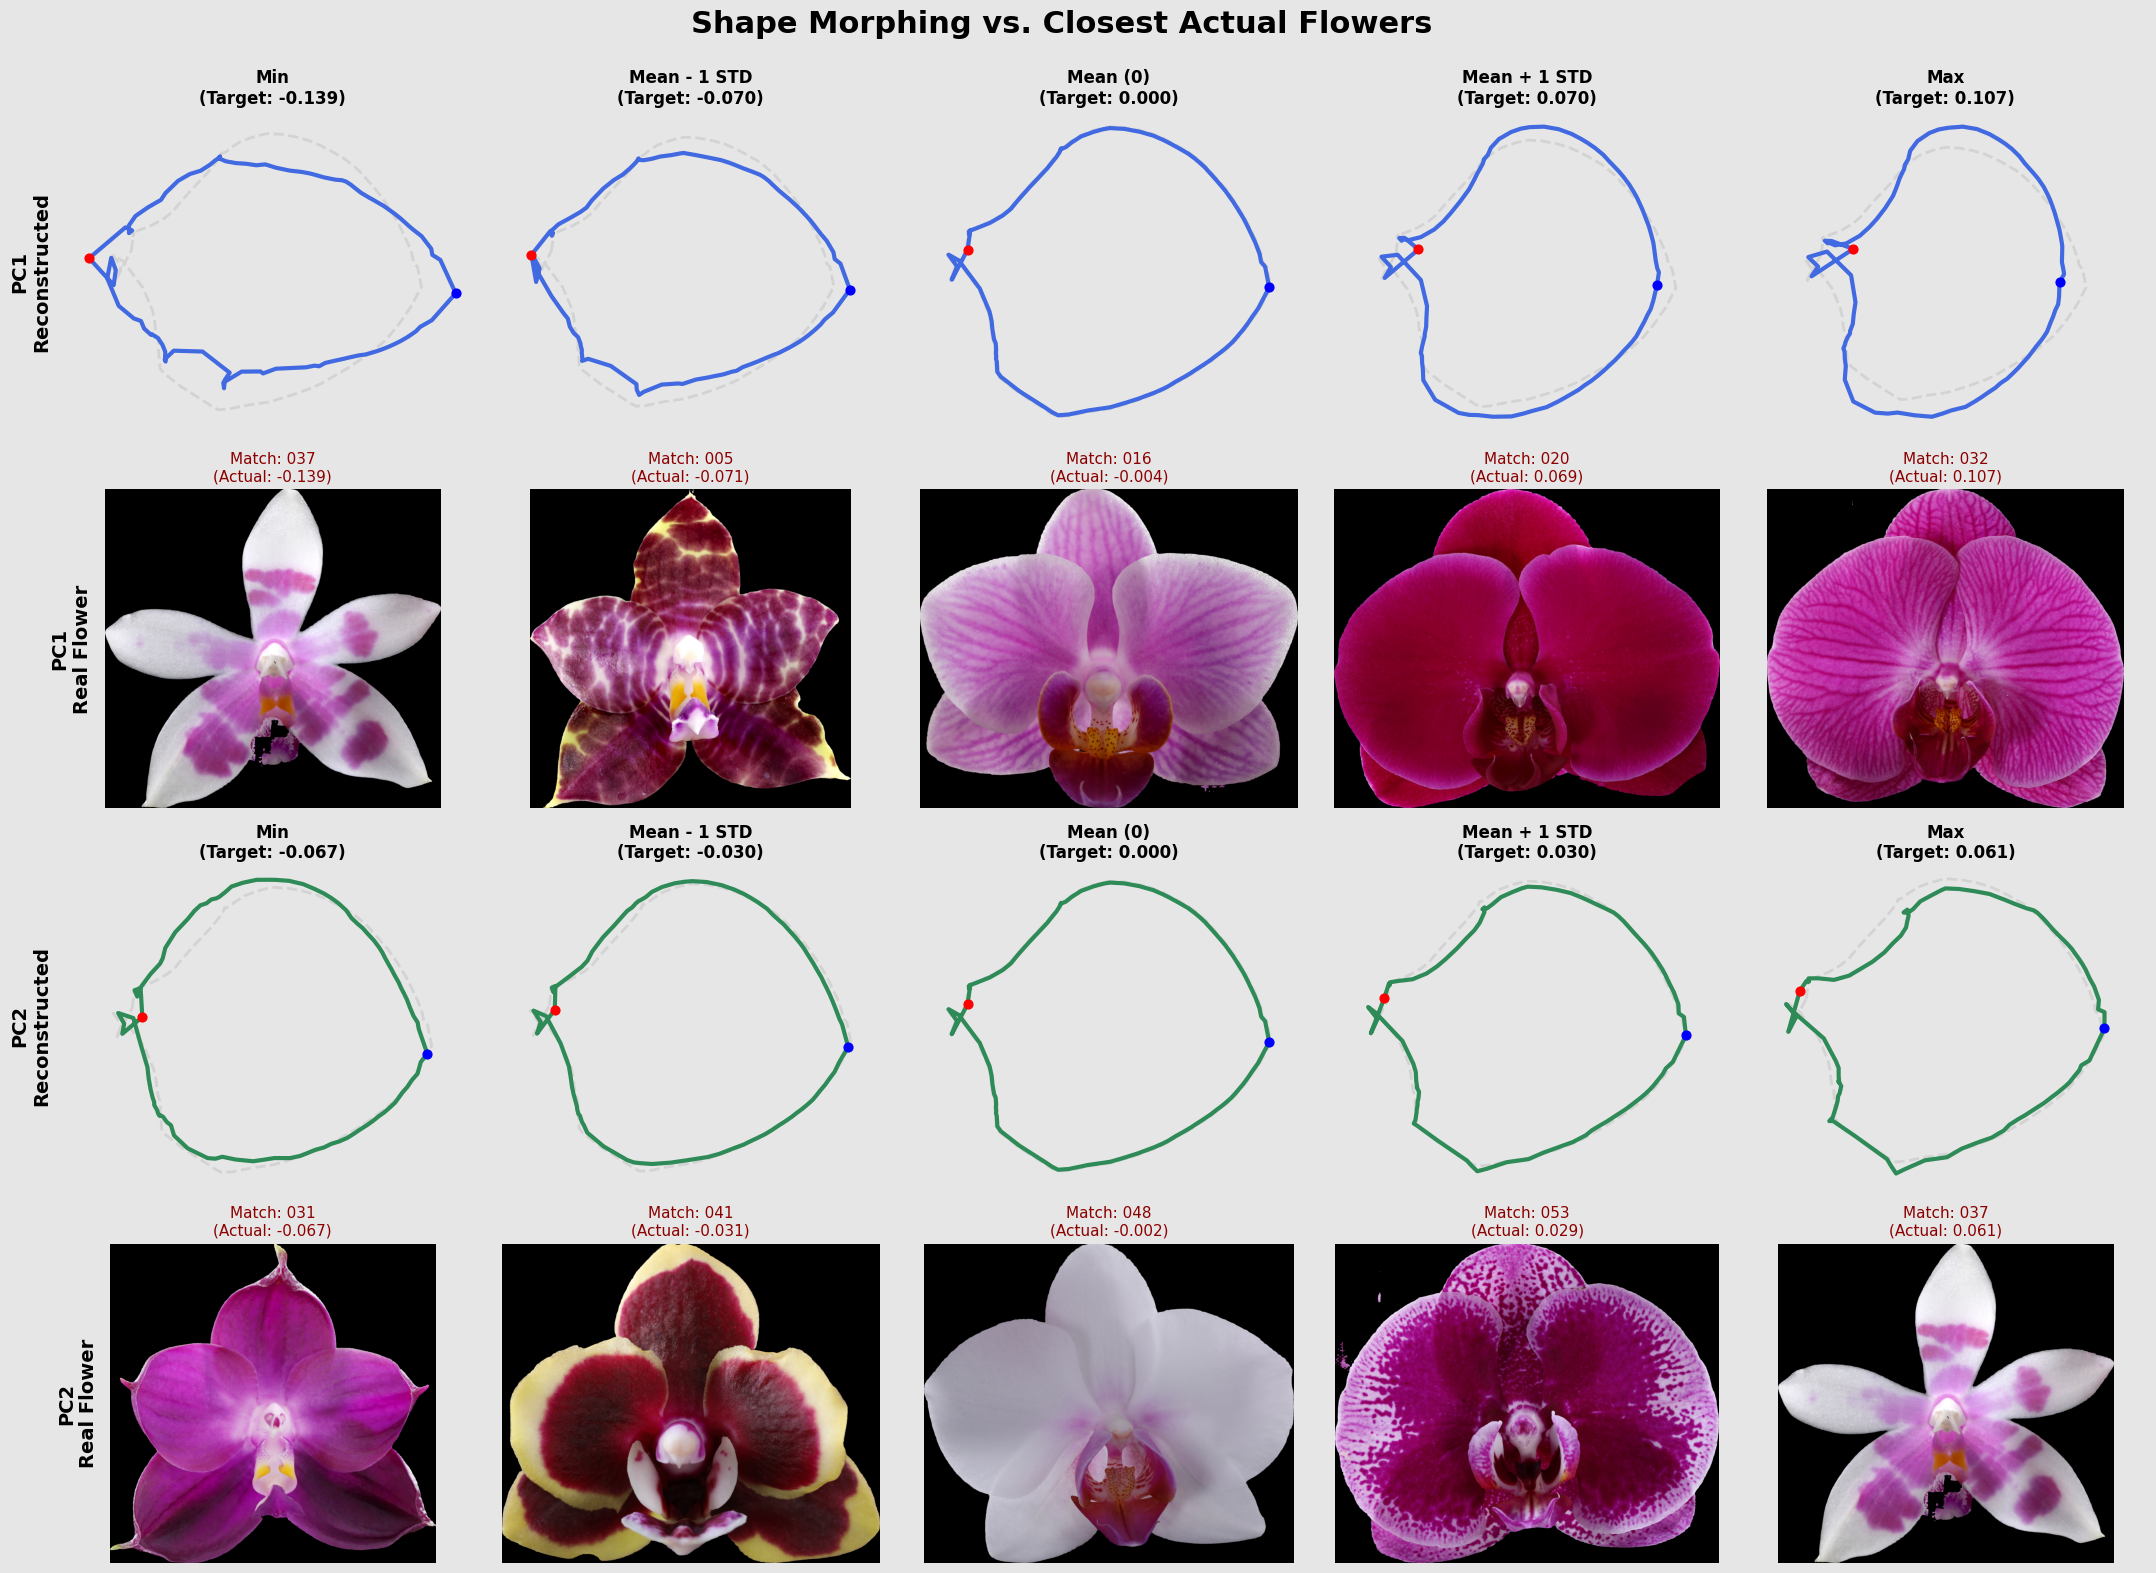

In [5]:
# ==========================================
# 6. 沿著主成分的漸進形狀重建與真實照片對比
# ==========================================
import os
import cv2
bg_color = '#E7E6E6'
bg_rgb = (231, 230, 230)
print("\n[*] 正在進行沿著主成分的漸進形狀重建與真實照片配對...")
 
# 1. 計算 PC1 與 PC2 的統計數值
pc1_scores = pcs[:, 0]
pc2_scores = pcs[:, 1]

pc1_std = np.std(pc1_scores)
pc2_std = np.std(pc2_scores)

pc1_targets = [np.min(pc1_scores), -pc1_std, 0, pc1_std, np.max(pc1_scores)]
pc2_targets = [np.min(pc2_scores), -pc2_std, 0, pc2_std, np.max(pc2_scores)]
labels = ["Min", "Mean - 1 STD", "Mean (0)", "Mean + 1 STD", "Max"]

# 2. 建立虛擬點進入 PCA 空間
syn_pc1 = np.zeros((5, 2))
syn_pc1[:, 0] = pc1_targets 
syn_pc2 = np.zeros((5, 2))
syn_pc2[:, 1] = pc2_targets 

# 3. 逆轉換回原始特徵空間
recon_pc1_shapes = pca.inverse_transform(syn_pc1).reshape(5, num_points, dims)
recon_pc2_shapes = pca.inverse_transform(syn_pc2).reshape(5, num_points, dims)

# 4. 輔助函式：尋找最接近目標分數的真實樣本 Index
def get_closest_sample_idx(scores_array, target_score):
    return np.argmin(np.abs(scores_array - target_score))

# 5. 繪製 4x5 網格圖 (加上真實照片)f
fig_recon, axes_recon = plt.subplots(4, 5, figsize=(22, 16))
fig_recon.set_facecolor(bg_color) # 替整張畫布設定底色
fig_recon.suptitle("Shape Morphing vs. Closest Actual Flowers", fontsize=22, fontweight='bold', y=0.98)

def plot_reconstructed_shape(ax, shape, color, title):
    """繪製單一重建形狀"""
    mean_closed_x = np.append(mean_shape[:, 0], mean_shape[0, 0])
    mean_closed_y = np.append(mean_shape[:, 1], mean_shape[0, 1])
    ax.plot(mean_closed_x, mean_closed_y, color='lightgray', linestyle='--', linewidth=2, zorder=1)
    
    closed_x = np.append(shape[:, 0], shape[0, 0])
    closed_y = np.append(shape[:, 1], shape[0, 1])
    ax.plot(closed_x, closed_y, color=color, linewidth=3, zorder=2)
    
    ax.scatter(shape[0, 0], shape[0, 1], color='red', s=40, zorder=3)
    ax.scatter(shape[50, 0], shape[50, 1], color='blue', s=40, zorder=3)
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.axis('equal')
    ax.axis('off')

def plot_closest_image(ax, actual_idx, target_score, is_pc1=True):
    """讀取並繪製最接近的原圖"""
    actual_label = valid_filenames[actual_idx]
    actual_score = pc1_scores[actual_idx] if is_pc1 else pc2_scores[actual_idx]
    
    # 透過檔名標籤找回原圖路徑
    img_path = os.path.join(image_dir, f"{actual_label}.png")
    
    if os.path.exists(img_path):
        # 使用 IMREAD_UNCHANGED 保留透明通道
        img = cv2.imread(img_path, cv2.IMREAD_UNCHANGED)
        if img is not None:
            if len(img.shape) == 3 and img.shape[-1] == 4: # 處理帶有去背的 PNG
                alpha = img[:, :, 3] / 255.0
                img_rgb = cv2.cvtColor(img[:, :, :3], cv2.COLOR_BGR2RGB)
                
                # 建立指定顏色的底色陣列
                bg = np.empty_like(img_rgb)
                bg[:] = bg_rgb
                
                # 合成：(原圖 * alpha) + (底色 * (1 - alpha))
                img_rgb = (img_rgb * alpha[..., None] + bg * (1 - alpha[..., None])).astype(np.uint8)
            else:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                
            ax.imshow(img_rgb)
    else:
        ax.text(0.5, 0.5, "Image Not Found", ha='center', va='center')
        
    ax.set_title(f"Match: {actual_label}\n(Actual: {actual_score:.3f})", fontsize=11, color='darkred')
    ax.axis('off')

# ... (後略：下方的 for 迴圈與 plt.show() 不變) ...


# --- 繪製 PC1 區塊 (Row 0: 虛擬重建, Row 1: 真實照片) ---
for i in range(5):
    # 畫重建形狀
    title = f"{labels[i]}\n(Target: {pc1_targets[i]:.3f})"
    plot_reconstructed_shape(axes_recon[0, i], recon_pc1_shapes[i], 'royalblue', title)
    
    # 找最接近的照片並畫出
    closest_idx = get_closest_sample_idx(pc1_scores, pc1_targets[i])
    plot_closest_image(axes_recon[1, i], closest_idx, pc1_targets[i], is_pc1=True)

# 加上列標籤
axes_recon[0, 0].text(-0.1, 0.5, "PC1\nReconstructed", transform=axes_recon[0, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')
axes_recon[1, 0].text(-0.1, 0.5, "PC1\nReal Flower", transform=axes_recon[1, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')

# --- 繪製 PC2 區塊 (Row 2: 虛擬重建, Row 3: 真實照片) ---
for i in range(5):
    title = f"{labels[i]}\n(Target: {pc2_targets[i]:.3f})"
    plot_reconstructed_shape(axes_recon[2, i], recon_pc2_shapes[i], 'seagreen', title)
    
    closest_idx = get_closest_sample_idx(pc2_scores, pc2_targets[i])
    plot_closest_image(axes_recon[3, i], closest_idx, pc2_targets[i], is_pc1=False)

# 加上列標籤
axes_recon[2, 0].text(-0.1, 0.5, "PC2\nReconstructed", transform=axes_recon[2, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')
axes_recon[3, 0].text(-0.1, 0.5, "PC2\nReal Flower", transform=axes_recon[3, 0].transAxes, fontsize=14, fontweight='bold', rotation=90, va='center', ha='center')

plt.tight_layout(rect=[0.02, 0, 1, 0.98]) # 預留左側標籤空間
plt.show()

# 主成分佔比分析

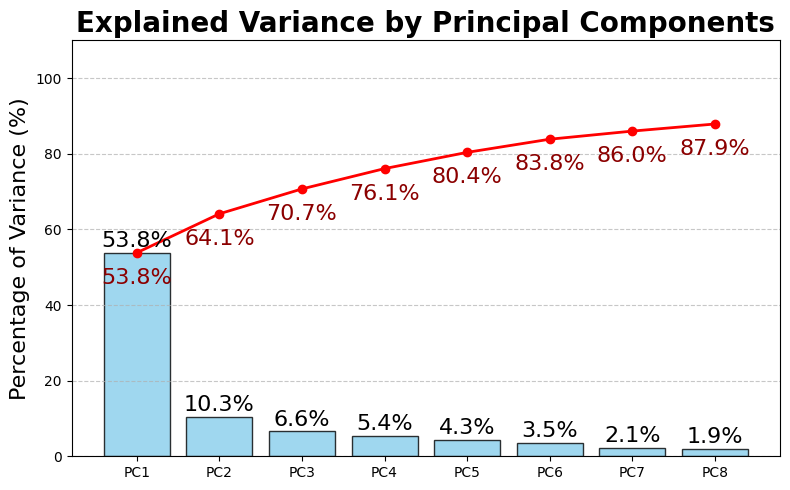

In [6]:
# ==========================================
# 繪製主成分解釋變異佔比直方圖 (Scree Plot)
# ==========================================
max_components = min(8, N - 1)
pca_multi = PCA(n_components=max_components)
pca_multi.fit(flattened_shapes)

explained_var = pca_multi.explained_variance_ratio_ * 100
cumulative_var = np.cumsum(explained_var)
x_labels = [f"PC{i+1}" for i in range(max_components)]

fig_var, ax_var = plt.subplots(figsize=(8, 5))
bars = ax_var.bar(x_labels, explained_var, color='skyblue', edgecolor='black', alpha=0.8)

for bar in bars:
    yval = bar.get_height()
    ax_var.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval:.1f}%", ha='center', va='bottom', fontsize=16)
    
ax_var.plot(x_labels, cumulative_var, color='red', marker='o', linewidth=2)
for i, val in enumerate(cumulative_var):
    ax_var.text(i, val - 4, f"{val:.1f}%", ha='center', va='top', color='darkred', fontsize=16)
    
ax_var.set_title("Explained Variance by Principal Components", fontsize=20, fontweight='bold')
ax_var.set_ylabel("Percentage of Variance (%)", fontsize=16)
ax_var.set_ylim(0, 110)
ax_var.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 計算傳統幾何特徵 (長寬比) 並存入表格

In [20]:
import pandas as pd
import math

# ==========================================
# 定義生物學中軸與寬度分析函式
# ==========================================
def get_aspect_ratio(binary_mask, origin_point):
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p)
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    true_width, aspect_ratio = 0, 0
    if true_length > 0:
        unit_axis = axis_vector / true_length
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj, max_neg_proj = 0, 0
        for pt in cnt:
            proj_dist = np.dot(np.array(pt[0], dtype=float) - base_np, perp_vector)
            if proj_dist > max_pos_proj: max_pos_proj = proj_dist
            elif proj_dist < max_neg_proj: max_neg_proj = proj_dist
                
        true_width = max_pos_proj - max_neg_proj 
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {"length": true_length, "width": true_width, "aspect_ratio": aspect_ratio}

# ==========================================
# 批次提取對應的長寬比數據
# ==========================================
print("[*] 正在計算傳統幾何特徵...")
traditional_metrics = []

for idx, label in enumerate(valid_filenames):
    # 解析檔名以讀取對應的 Mask
    base_name = label.split('_p')[0]
    mask_path = os.path.join(mask_dir, f"{base_name}.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    
    # 尋找柱頭原點
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    if M_c1["m00"] == 0: continue
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    # 針對花瓣 (Class 7) 進行計算
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    
    # 簡化處理：假設單一影像中面積最大的對應，或是直接提取
    # 這裡直接取用最大的花瓣計算 (若有多花瓣，此處以整體 Class 7 代表)
    metrics = get_aspect_ratio(mask_c7, column_centroid)
    
    if metrics:
        traditional_metrics.append({
            "Filename": label,
            "PC1_Score": pcs[idx, 0],
            "True_Length": metrics["length"],
            "True_Width": metrics["width"],
            "Aspect_Ratio": metrics["aspect_ratio"]
        })


# ==========================================
# 定義生物學中軸與寬度、凸包(Solidity)分析函式
# ==========================================
def get_traditional_metrics(binary_mask, origin_point):
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: return None
    cnt = max(contours, key=cv2.contourArea)
    
    # 🌟 新增：計算面積與凸包 (Solidity) 🌟
    area = cv2.contourArea(cnt)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0
    
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p)
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    true_width, aspect_ratio = 0, 0
    if true_length > 0:
        unit_axis = axis_vector / true_length
        perp_vector = np.array([-unit_axis[1], unit_axis[0]])
        
        max_pos_proj, max_neg_proj = 0, 0
        for pt in cnt:
            proj_dist = np.dot(np.array(pt[0], dtype=float) - base_np, perp_vector)
            if proj_dist > max_pos_proj: max_pos_proj = proj_dist
            elif proj_dist < max_neg_proj: max_neg_proj = proj_dist
                
        true_width = max_pos_proj - max_neg_proj 
        aspect_ratio = true_length / true_width if true_width > 0 else 0

    return {
        "length": true_length, 
        "width": true_width, 
        "aspect_ratio": aspect_ratio,
        "solidity": solidity  # 🌟 輸出 Solidity
    }

# ==========================================
# 批次提取數據並存入 DataFrame
# ==========================================
print("[*] 正在計算傳統幾何特徵 (包含 Aspect Ratio 與 Solidity)...")
traditional_metrics = []

# 確保迴圈順序與 valid_filenames 絕對一致
for idx, label in enumerate(valid_filenames):
    base_name = label.split('_p')[0]
    mask_path = os.path.join(mask_dir, f"{base_name}.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None: continue
    
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    if M_c1["m00"] == 0: continue
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    metrics = get_traditional_metrics(mask_c7, column_centroid)
    
    if metrics:
        traditional_metrics.append({
            "Filename": label,
            "PC1_Score": pcs[idx, 0],
            "PC2_Score": pcs[idx, 1],
            "True_Length": metrics["length"],
            "True_Width": metrics["width"],
            "Aspect_Ratio": metrics["aspect_ratio"],
            "Solidity": metrics["solidity"]  # 🌟 寫入 DF
        })


df_metrics = pd.DataFrame(traditional_metrics)
display(df_metrics) # 渲染表格，你會在最右邊看到新的 Solidity 欄位




[*] 正在計算傳統幾何特徵...
[*] 正在計算傳統幾何特徵 (包含 Aspect Ratio 與 Solidity)...


,Filename,PC1_Score,PC2_Score,True_Length,True_Width,Aspect_Ratio,Solidity
0,001,0.061947,-0.018098,1802.905433,2260.643252,0.797519,0.923789
1,002,0.055856,0.012438,1539.310235,1784.510969,0.862595,0.940695
2,003,0.049249,0.027308,1471.392538,1715.925516,0.857492,0.965612
3,004,0.085741,0.022862,1380.452824,1742.885347,0.792050,0.898733
4,005,-0.070847,-0.052287,1495.446756,1127.500523,1.326338,0.973366
5,006,-0.013642,0.024098,1501.172875,1301.587600,1.153340,0.932616
6,007,-0.022663,0.005529,1505.314917,1282.495096,1.173739,0.972505
7,008,-0.017503,-0.024086,1993.669983,1834.229352,1.086925,0.931701
8,009,-0.117220,0.043565,1673.946534,1008.176764,1.660370,0.975124
9,010,-0.118180,0.023076,1555.610491,903.669658,1.721437,0.985350


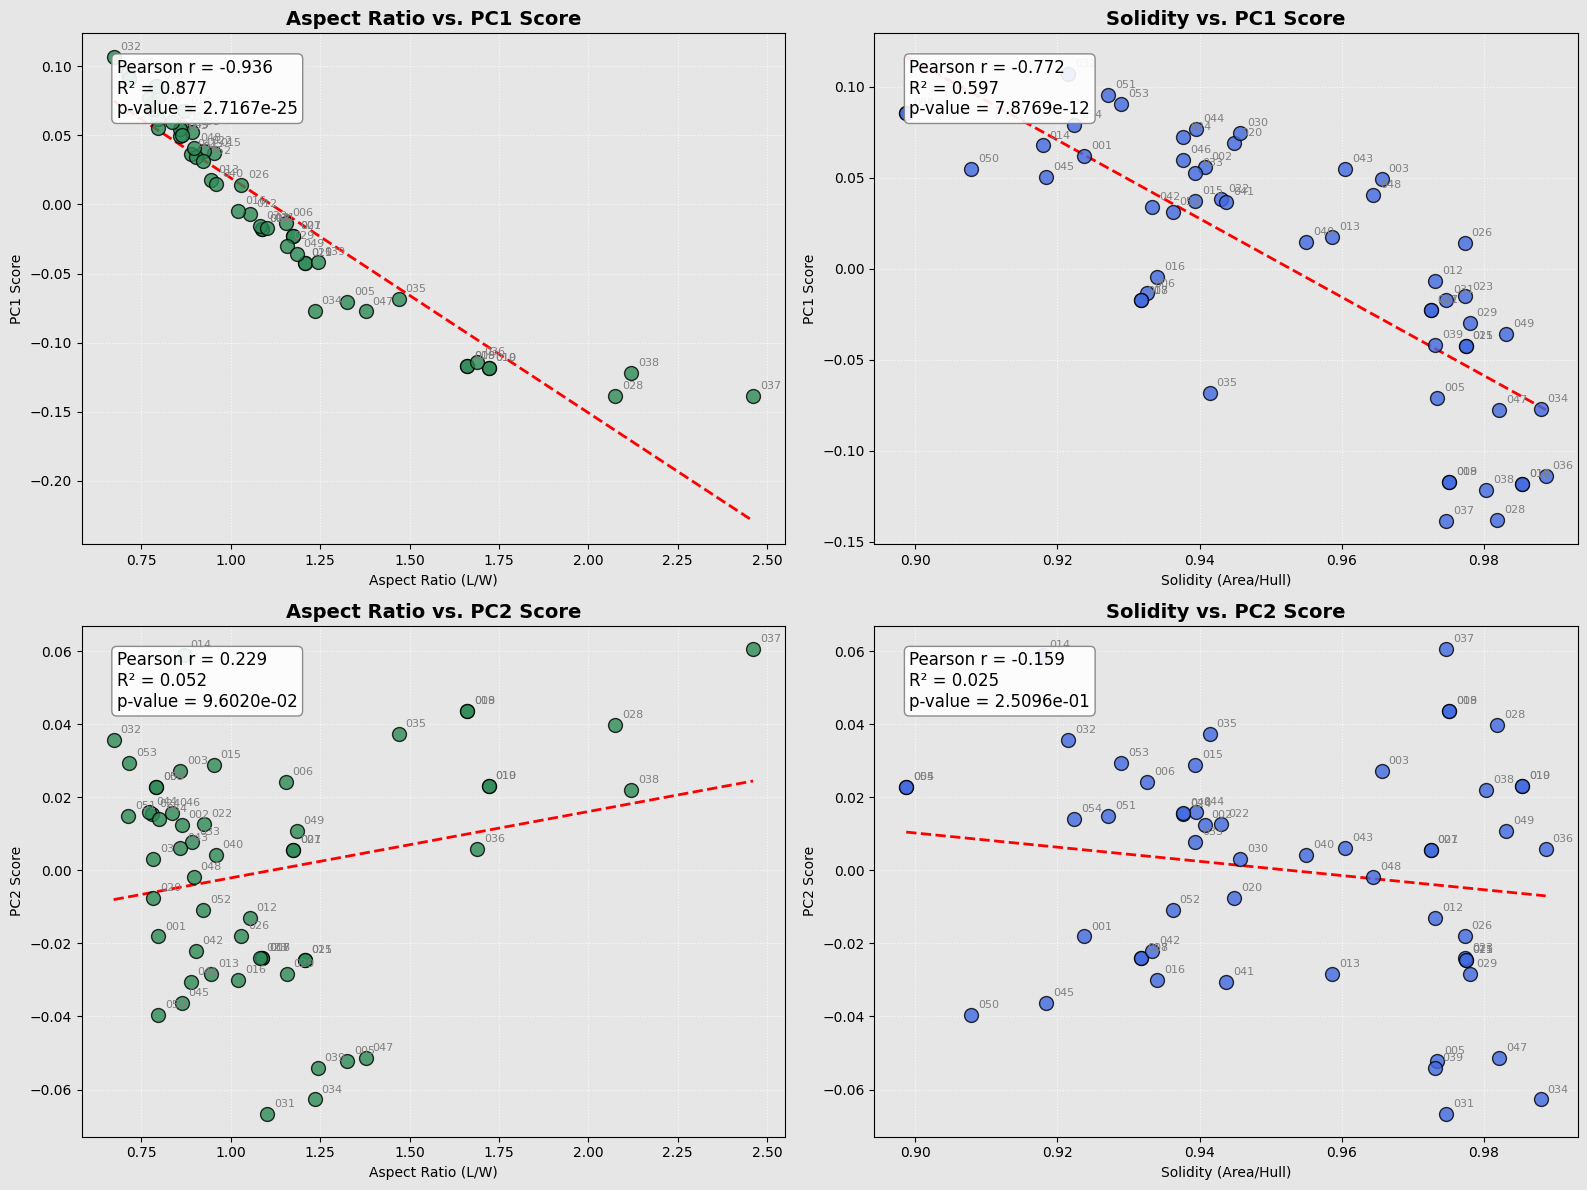

         🔬 形態學交叉驗證結論報告 (長寬比 & Solidity vs PC1/PC2)          
【PC1 分析】
1. 傳統長寬比 (Aspect Ratio)：
     -> 顯著相關 (p = 2.7167e-25)，R² = 0.877
2. 輪廓實心度/凸包比 (Solidity)：
     -> 顯著相關 (p = 7.8769e-12)，R² = 0.597

【PC2 分析】
1. 傳統長寬比 (Aspect Ratio)：
     -> 無顯著相關 (p = 9.6020e-02)
2. 輪廓實心度/凸包比 (Solidity)：
     -> 無顯著相關 (p = 2.5096e-01)

💡 綜合結論推論：
   - 若 PC 與 Aspect Ratio 相關，代表該維度實質捕捉了花瓣整體狹長比例的拉伸。
   - 若 PC 與 Solidity 相關，代表該維度反映了花瓣邊緣的複雜度、波浪缺刻或是基部的劇烈收縮。


In [21]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 提取 DataFrame 中的數值進行迴歸分析
# ==========================================
aspect_ratios_array = df_metrics['Aspect_Ratio'].values
solidity_array = df_metrics['Solidity'].values
pc1_scores_array = df_metrics['PC1_Score'].values
pc2_scores_array = df_metrics['PC2_Score'].values 

# 計算 PC1 的統計量
slope_ar_1, intcpt_ar_1, r_ar_1, p_ar_1, _ = stats.linregress(aspect_ratios_array, pc1_scores_array)
slope_sol_1, intcpt_sol_1, r_sol_1, p_sol_1, _ = stats.linregress(solidity_array, pc1_scores_array)

# 計算 PC2 的統計量
slope_ar_2, intcpt_ar_2, r_ar_2, p_ar_2, _ = stats.linregress(aspect_ratios_array, pc2_scores_array)
slope_sol_2, intcpt_sol_2, r_sol_2, p_sol_2, _ = stats.linregress(solidity_array, pc2_scores_array)

# ==========================================
# 2. 繪製相關性散佈圖 (2x2 雙圖並排)
# ==========================================
bg_color = '#E7E6E6'
fig_corr, axes = plt.subplots(2, 2, figsize=(16, 12))
fig_corr.set_facecolor(bg_color)

def plot_regression(ax, x_data, y_data, slope, intercept, r_val, p_val, x_label, y_label, color, title):
    """輔助繪圖函式，減少重複的程式碼"""
    ax.set_facecolor(bg_color)
    ax.scatter(x_data, y_data, color=color, s=100, alpha=0.8, edgecolors='k', zorder=3)
    
    # 趨勢線
    trendline_x = np.linspace(min(x_data), max(x_data), 100)
    ax.plot(trendline_x, slope * trendline_x + intercept, color='red', linestyle='--', linewidth=2, zorder=2)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    
    # 統計標籤
    stats_text = f"Pearson r = {r_val:.3f}\nR² = {r_val**2:.3f}\np-value = {p_val:.4e}"
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=12, verticalalignment='top', 
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray'), zorder=5)

    # 檔名標註
    for i, label in enumerate(df_metrics['Filename']):
        ax.annotate(label, (x_data[i], y_data[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray', zorder=4)
        
    ax.grid(True, linestyle=':', alpha=0.8, color='white', zorder=0)

# --- 繪製 Row 0: PC1 分析 ---
plot_regression(axes[0, 0], aspect_ratios_array, pc1_scores_array, slope_ar_1, intcpt_ar_1, r_ar_1, p_ar_1, 
                "Aspect Ratio (L/W)", "PC1 Score", 'seagreen', "Aspect Ratio vs. PC1 Score")
plot_regression(axes[0, 1], solidity_array, pc1_scores_array, slope_sol_1, intcpt_sol_1, r_sol_1, p_sol_1, 
                "Solidity (Area/Hull)", "PC1 Score", 'royalblue', "Solidity vs. PC1 Score")

# --- 繪製 Row 1: PC2 分析 ---
plot_regression(axes[1, 0], aspect_ratios_array, pc2_scores_array, slope_ar_2, intcpt_ar_2, r_ar_2, p_ar_2, 
                "Aspect Ratio (L/W)", "PC2 Score", 'seagreen', "Aspect Ratio vs. PC2 Score")
plot_regression(axes[1, 1], solidity_array, pc2_scores_array, slope_sol_2, intcpt_sol_2, r_sol_2, p_sol_2, 
                "Solidity (Area/Hull)", "PC2 Score", 'royalblue', "Solidity vs. PC2 Score")

plt.tight_layout()
plt.show()

# ==========================================
# 3. 終端機列印科學結論
# ==========================================
def print_stats(p, r_val):
    if p < 0.05:
        print(f"     -> 顯著相關 (p = {p:.4e})，R² = {r_val**2:.3f}")
    else:
        print(f"     -> 無顯著相關 (p = {p:.4e})")

print("="*70)
print(f"{'🔬 形態學交叉驗證結論報告 (長寬比 & Solidity vs PC1/PC2)':^60}")
print("="*70)

print("【PC1 分析】")
print("1. 傳統長寬比 (Aspect Ratio)：")
print_stats(p_ar_1, r_ar_1)
print("2. 輪廓實心度/凸包比 (Solidity)：")
print_stats(p_sol_1, r_sol_1)

print("\n【PC2 分析】")
print("1. 傳統長寬比 (Aspect Ratio)：")
print_stats(p_ar_2, r_ar_2)
print("2. 輪廓實心度/凸包比 (Solidity)：")
print_stats(p_sol_2, r_sol_2)

print("\n💡 綜合結論推論：")
print("   - 若 PC 與 Aspect Ratio 相關，代表該維度實質捕捉了花瓣整體狹長比例的拉伸。")
print("   - 若 PC 與 Solidity 相關，代表該維度反映了花瓣邊緣的複雜度、波浪缺刻或是基部的劇烈收縮。")
print("="*70)


# 相關性檢定：PC1 vs 長寬比

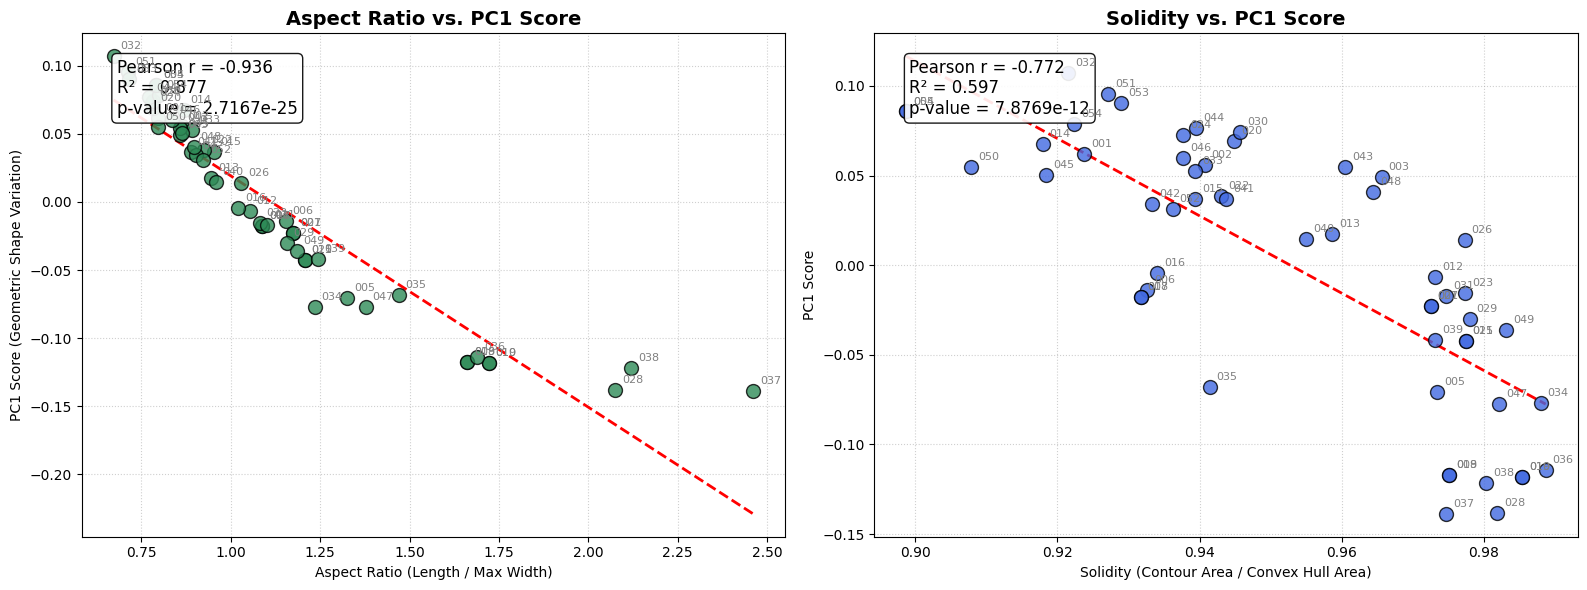

              🔬 形態學交叉驗證結論報告 (長寬比 vs Solidity)               
【1】傳統長寬比 (Aspect Ratio)：
     -> 顯著相關 (p = 2.7167e-25)，R² = 0.877

【2】輪廓實心度/凸包比 (Solidity)：
     -> 顯著相關 (p = 7.8769e-12)，R² = 0.597
     💡 結論：PC1 捕捉到的重要形狀變異，實質上反映了花瓣的「邊緣複雜度」。
        這可能代表某些物種的花瓣邊緣有明顯的波浪、缺刻，或者基部收縮較劇烈。


In [18]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 提取 DataFrame 中的數值進行迴歸分析
# ==========================================
aspect_ratios_array = df_metrics['Aspect_Ratio'].values
solidity_array = df_metrics['Solidity'].values
pc1_scores_array = df_metrics['PC1_Score'].values

# 計算 1: 長寬比 vs PC1
slope_ar, intercept_ar, r_ar, p_ar, _ = stats.linregress(aspect_ratios_array, pc1_scores_array)
r2_ar = r_ar ** 2

# 計算 2: Solidity vs PC1 🌟
slope_sol, intercept_sol, r_sol, p_sol, _ = stats.linregress(solidity_array, pc1_scores_array)
r2_sol = r_sol ** 2

# ==========================================
# 繪製相關性散佈圖 (1x2 雙圖並排)
# ==========================================
fig_corr, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- 左圖：Aspect Ratio vs PC1 ---
axes[0].scatter(aspect_ratios_array, pc1_scores_array, color='seagreen', s=100, alpha=0.8, edgecolors='k', zorder=3)
trendline_x_ar = np.linspace(min(aspect_ratios_array), max(aspect_ratios_array), 100)
axes[0].plot(trendline_x_ar, slope_ar * trendline_x_ar + intercept_ar, color='red', linestyle='--', linewidth=2, zorder=2)

axes[0].set_title("Aspect Ratio vs. PC1 Score", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Aspect Ratio (Length / Max Width)")
axes[0].set_ylabel("PC1 Score (Geometric Shape Variation)")
stats_text_ar = f"Pearson r = {r_ar:.3f}\nR² = {r2_ar:.3f}\np-value = {p_ar:.4e}"
axes[0].text(0.05, 0.95, stats_text_ar, transform=axes[0].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

for i, label in enumerate(df_metrics['Filename']):
    axes[0].annotate(label, (aspect_ratios_array[i], pc1_scores_array[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')
axes[0].grid(True, linestyle=':', alpha=0.6, zorder=0)


# --- 右圖：Solidity vs PC1 🌟 ---
axes[1].scatter(solidity_array, pc1_scores_array, color='royalblue', s=100, alpha=0.8, edgecolors='k', zorder=3)
trendline_x_sol = np.linspace(min(solidity_array), max(solidity_array), 100)
axes[1].plot(trendline_x_sol, slope_sol * trendline_x_sol + intercept_sol, color='red', linestyle='--', linewidth=2, zorder=2)

axes[1].set_title("Solidity vs. PC1 Score", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Solidity (Contour Area / Convex Hull Area)")
axes[1].set_ylabel("PC1 Score")
stats_text_sol = f"Pearson r = {r_sol:.3f}\nR² = {r2_sol:.3f}\np-value = {p_sol:.4e}"
axes[1].text(0.05, 0.95, stats_text_sol, transform=axes[1].transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

for i, label in enumerate(df_metrics['Filename']):
    axes[1].annotate(label, (solidity_array[i], pc1_scores_array[i]), xytext=(5, 5), textcoords='offset points', fontsize=8, color='gray')
axes[1].grid(True, linestyle=':', alpha=0.6, zorder=0)

plt.tight_layout()
plt.show()

# ==========================================
# 終端機列印科學結論
# ==========================================
print("="*70)
print(f"{'🔬 形態學交叉驗證結論報告 (長寬比 vs Solidity)':^60}")
print("="*70)

print("【1】傳統長寬比 (Aspect Ratio)：")
if p_ar < 0.05:
    print(f"     -> 顯著相關 (p = {p_ar:.4e})，R² = {r2_ar:.3f}")
else:
    print(f"     -> 無顯著相關 (p = {p_ar:.4e})")

print("\n【2】輪廓實心度/凸包比 (Solidity)：")
if p_sol < 0.05:
    print(f"     -> 顯著相關 (p = {p_sol:.4e})，R² = {r2_sol:.3f}")
    print("     💡 結論：PC1 捕捉到的重要形狀變異，實質上反映了花瓣的「邊緣複雜度」。")
    print("        這可能代表某些物種的花瓣邊緣有明顯的波浪、缺刻，或者基部收縮較劇烈。")
else:
    print(f"     -> 無顯著相關 (p = {p_sol:.4e})")
    print("     💡 結論：PC1 代表的既不是單純的長寬比，也不是實心度。這群花瓣的形變")
    print("        可能牽涉到更非線性的特徵 (如花瓣重心的偏移、左右不對稱性)。")
print("="*70)

[*] 正在繪製所有花瓣的 Aspect Ratio 視覺化...


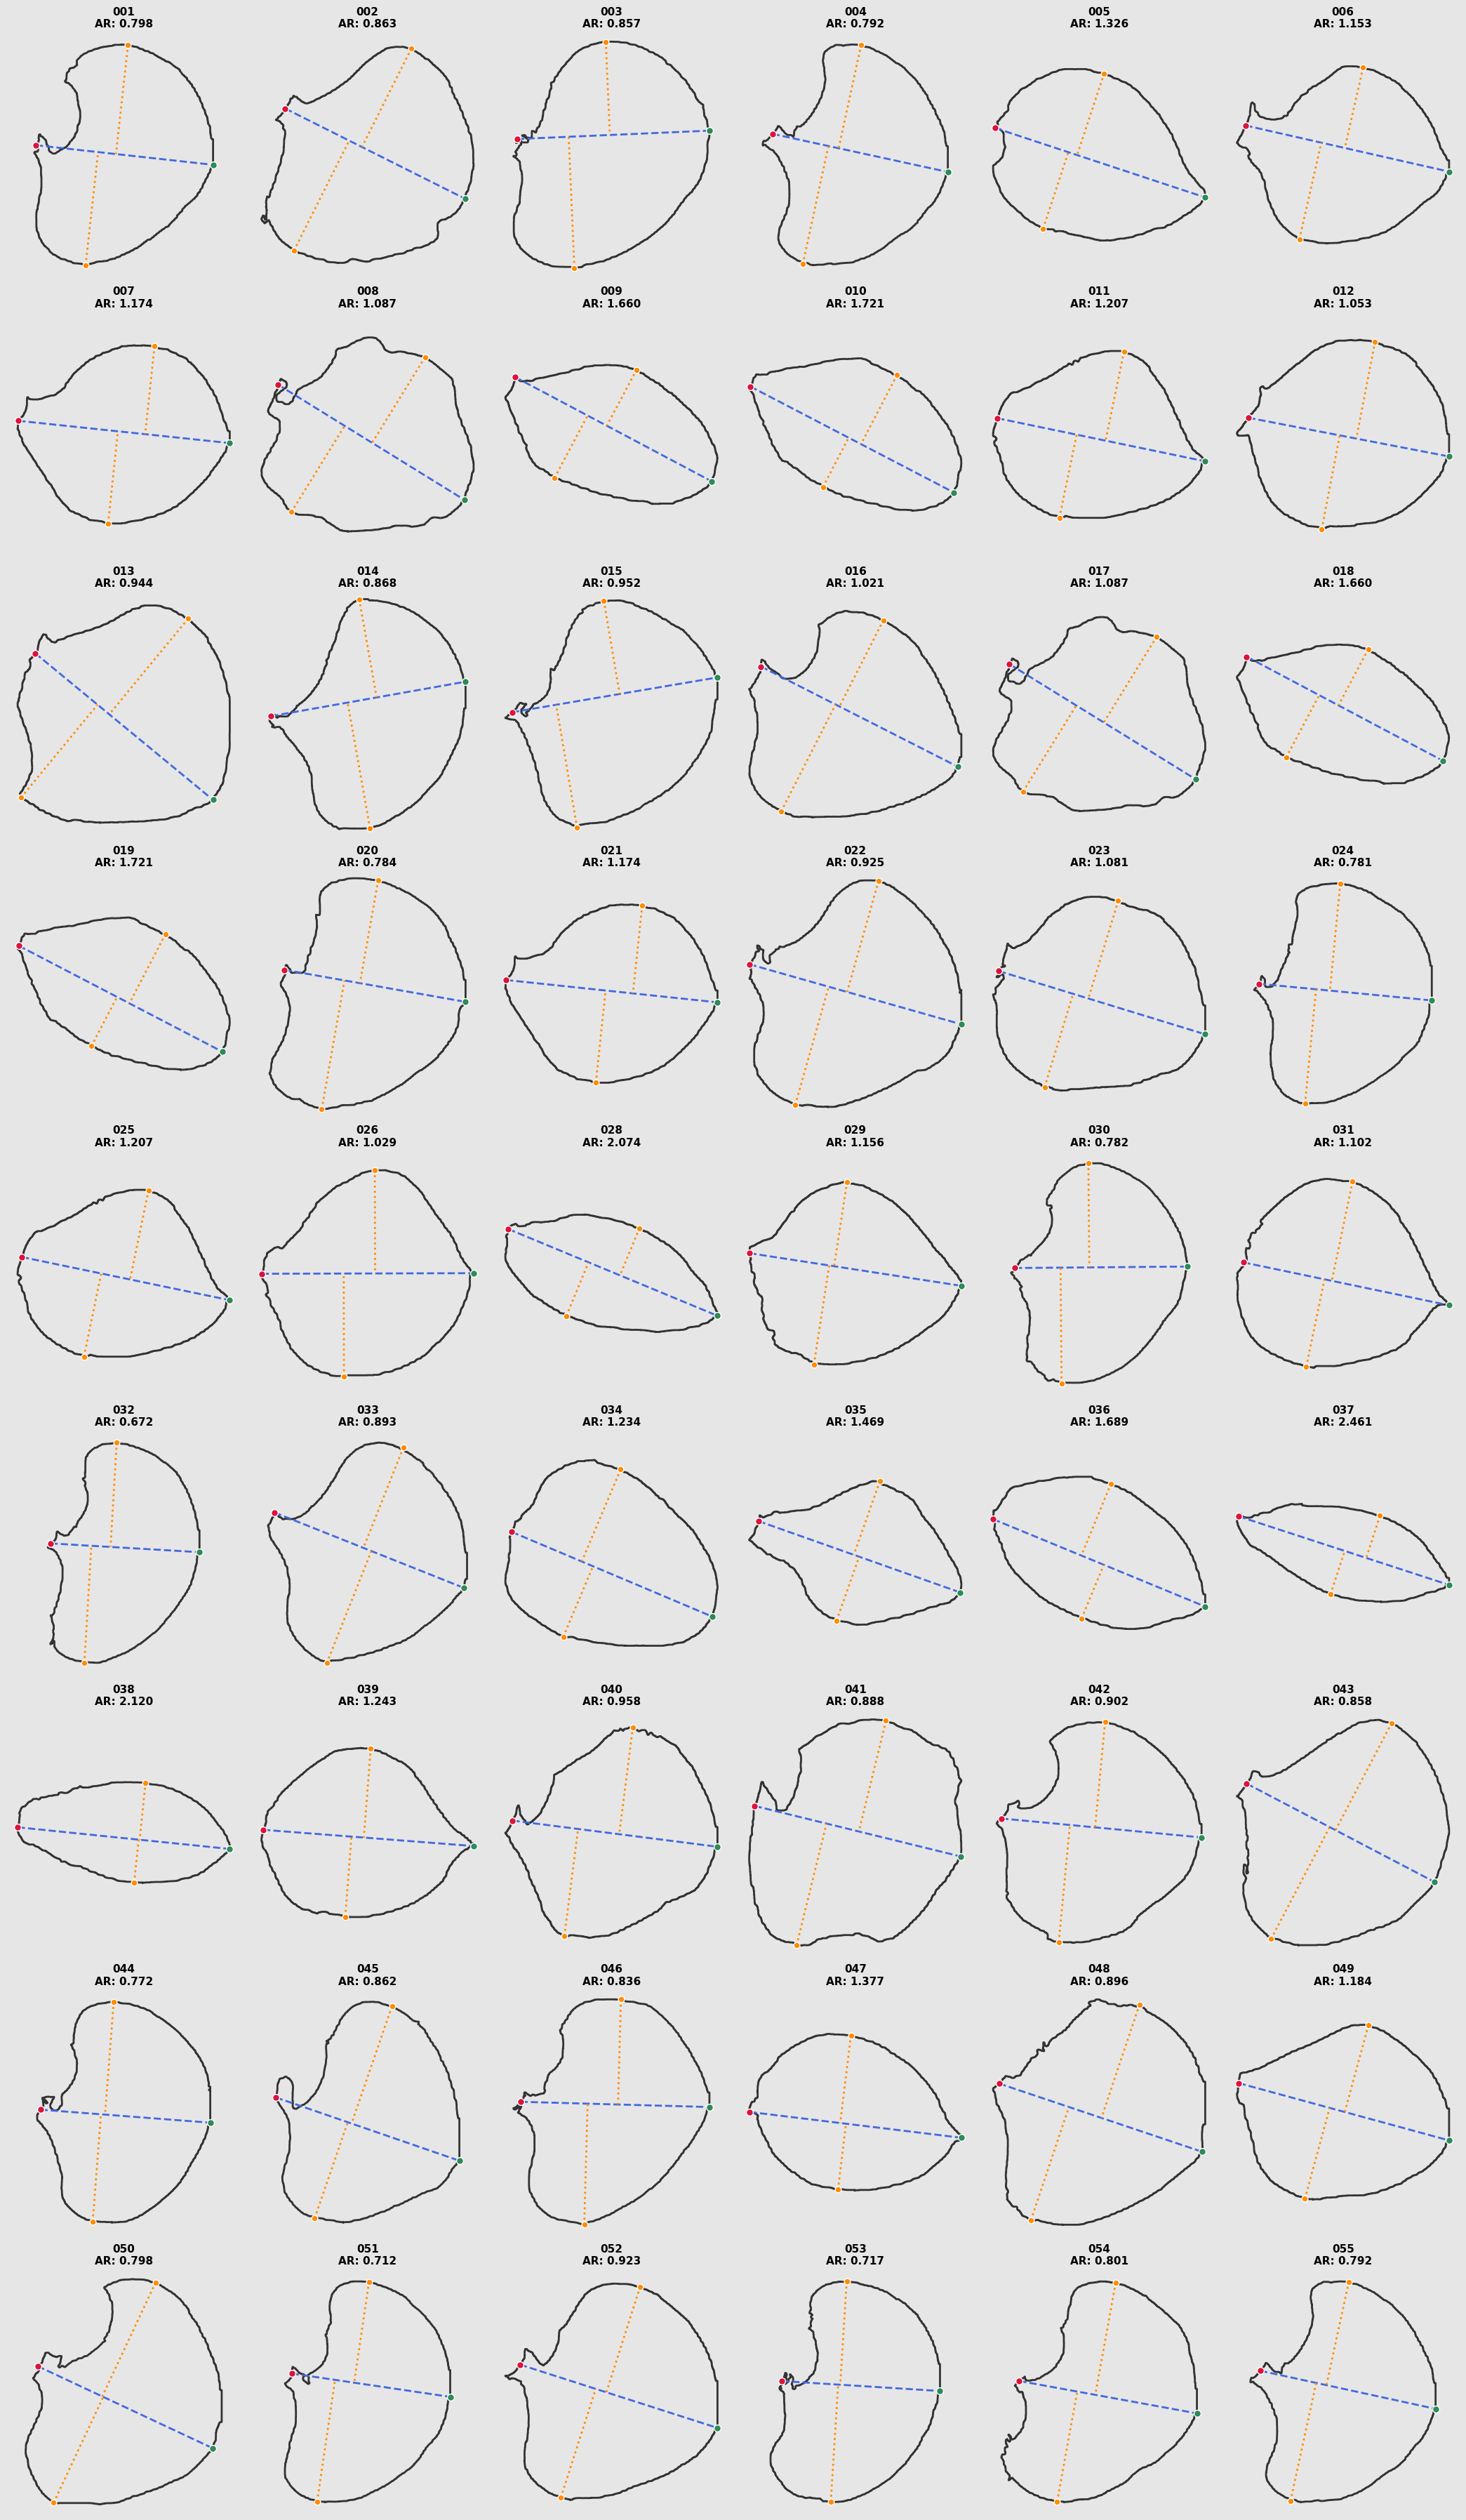

In [25]:
import math
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ==========================================
# 幾何特徵視覺化腳本 (Aspect Ratio)
# ==========================================
def plot_aspect_ratio_features(binary_mask, origin_point, ax, label_name):
    # 尋找乾淨的輪廓
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: 
        ax.text(0.5, 0.5, "No Contour", ha='center', va='center')
        ax.axis('off')
        return
        
    cnt = max(contours, key=cv2.contourArea)
    
    # 🌟 修正的 Bug：正確計算 Base (最近點) 與 Tip (最遠點)
    max_dist, min_dist = 0, float('inf')
    farthest_point, closest_point = None, None
    for pt in cnt:
        p = pt[0]
        dist = np.linalg.norm(p - origin_point)
        if dist > max_dist: max_dist, farthest_point = dist, tuple(p) # 補上 dist
        if dist < min_dist: min_dist, closest_point = dist, tuple(p)  # 補上 dist
            
    base_np = np.array(closest_point, dtype=float)
    tip_np = np.array(farthest_point, dtype=float)
    axis_vector = tip_np - base_np
    true_length = np.linalg.norm(axis_vector)
    
    if true_length == 0: return

    # 計算中軸方向與垂直法向量
    unit_axis = axis_vector / true_length
    perp_vector = np.array([-unit_axis[1], unit_axis[0]])
    
    # 計算寬度極值並紀錄該點座標
    max_pos_proj, max_neg_proj = 0, 0
    pos_pt, neg_pt = base_np, base_np 
    
    for pt in cnt:
        p = np.array(pt[0], dtype=float)
        proj_dist = np.dot(p - base_np, perp_vector)
        if proj_dist > max_pos_proj: 
            max_pos_proj = proj_dist
            pos_pt = p
        elif proj_dist < max_neg_proj: 
            max_neg_proj = proj_dist
            neg_pt = p
            
    true_width = max_pos_proj - max_neg_proj 
    aspect_ratio = true_length / true_width if true_width > 0 else 0

    # --- 開始繪圖 ---
    ax.set_facecolor('#E7E6E6')
    
    # 畫輪廓線 (深灰色)
    cnt_pts = np.vstack([cnt[:, 0, :], cnt[0, 0, :]])
    ax.plot(cnt_pts[:, 0], cnt_pts[:, 1], color='#333333', linewidth=2, zorder=2)
    
    # 畫生物學中軸 Length (藍色虛線)
    ax.plot([base_np[0], tip_np[0]], [base_np[1], tip_np[1]], color='royalblue', linewidth=2, linestyle='--', zorder=3)
    ax.scatter(base_np[0], base_np[1], color='crimson', s=50, zorder=5, edgecolors='white', label='Base')
    ax.scatter(tip_np[0], tip_np[1], color='seagreen', s=50, zorder=5, edgecolors='white', label='Tip')
    
    # 投影寬度點到中軸上
    proj_pos_axis = base_np + np.dot(pos_pt - base_np, unit_axis) * unit_axis
    proj_neg_axis = base_np + np.dot(neg_pt - base_np, unit_axis) * unit_axis
    
    # 畫出投影的 Width 寬度線 (橘色點狀線)
    ax.plot([pos_pt[0], proj_pos_axis[0]], [pos_pt[1], proj_pos_axis[1]], color='darkorange', linewidth=2, linestyle=':', zorder=3)
    ax.plot([neg_pt[0], proj_neg_axis[0]], [neg_pt[1], proj_neg_axis[1]], color='darkorange', linewidth=2, linestyle=':', zorder=3)
    ax.scatter([pos_pt[0], neg_pt[0]], [pos_pt[1], neg_pt[1]], color='darkorange', s=40, zorder=5, edgecolors='white')

    ax.set_title(f"{label_name}\nAR: {aspect_ratio:.3f}", fontsize=11, fontweight='bold')
    ax.axis('equal')
    ax.axis('off')

# ==========================================
# 批次生成網格視覺化
# ==========================================
print("[*] 正在繪製所有花瓣的 Aspect Ratio 視覺化...")

num_flowers = len(valid_filenames)
cols = 6  
rows = math.ceil(num_flowers / cols)

bg_color = '#E7E6E6'
fig_viz, axes_viz = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 4))
fig_viz.set_facecolor(bg_color)
axes_flat = axes_viz.flatten()

# 巡迴每一張有效影像繪圖
for idx, label in enumerate(valid_filenames):
    
    # 🌟 直接使用正確的 label.png
    mask_path = os.path.join(mask_dir, f"{label}.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    ax = axes_flat[idx]
    
    if mask is None: 
        ax.axis('off')
        continue
        
    # 補上 Padding，確保輪廓完整性
    mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
    
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    
    if M_c1["m00"] == 0: 
        ax.axis('off')
        continue
        
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    plot_aspect_ratio_features(mask_c7, column_centroid, ax, label)

# 隱藏多餘的空白子圖
for i in range(num_flowers, len(axes_flat)):
    axes_flat[i].axis('off')
    axes_flat[i].set_facecolor(bg_color)

plt.tight_layout()
plt.show()



[*] 正在繪製所有花瓣的 Solidity 視覺化...


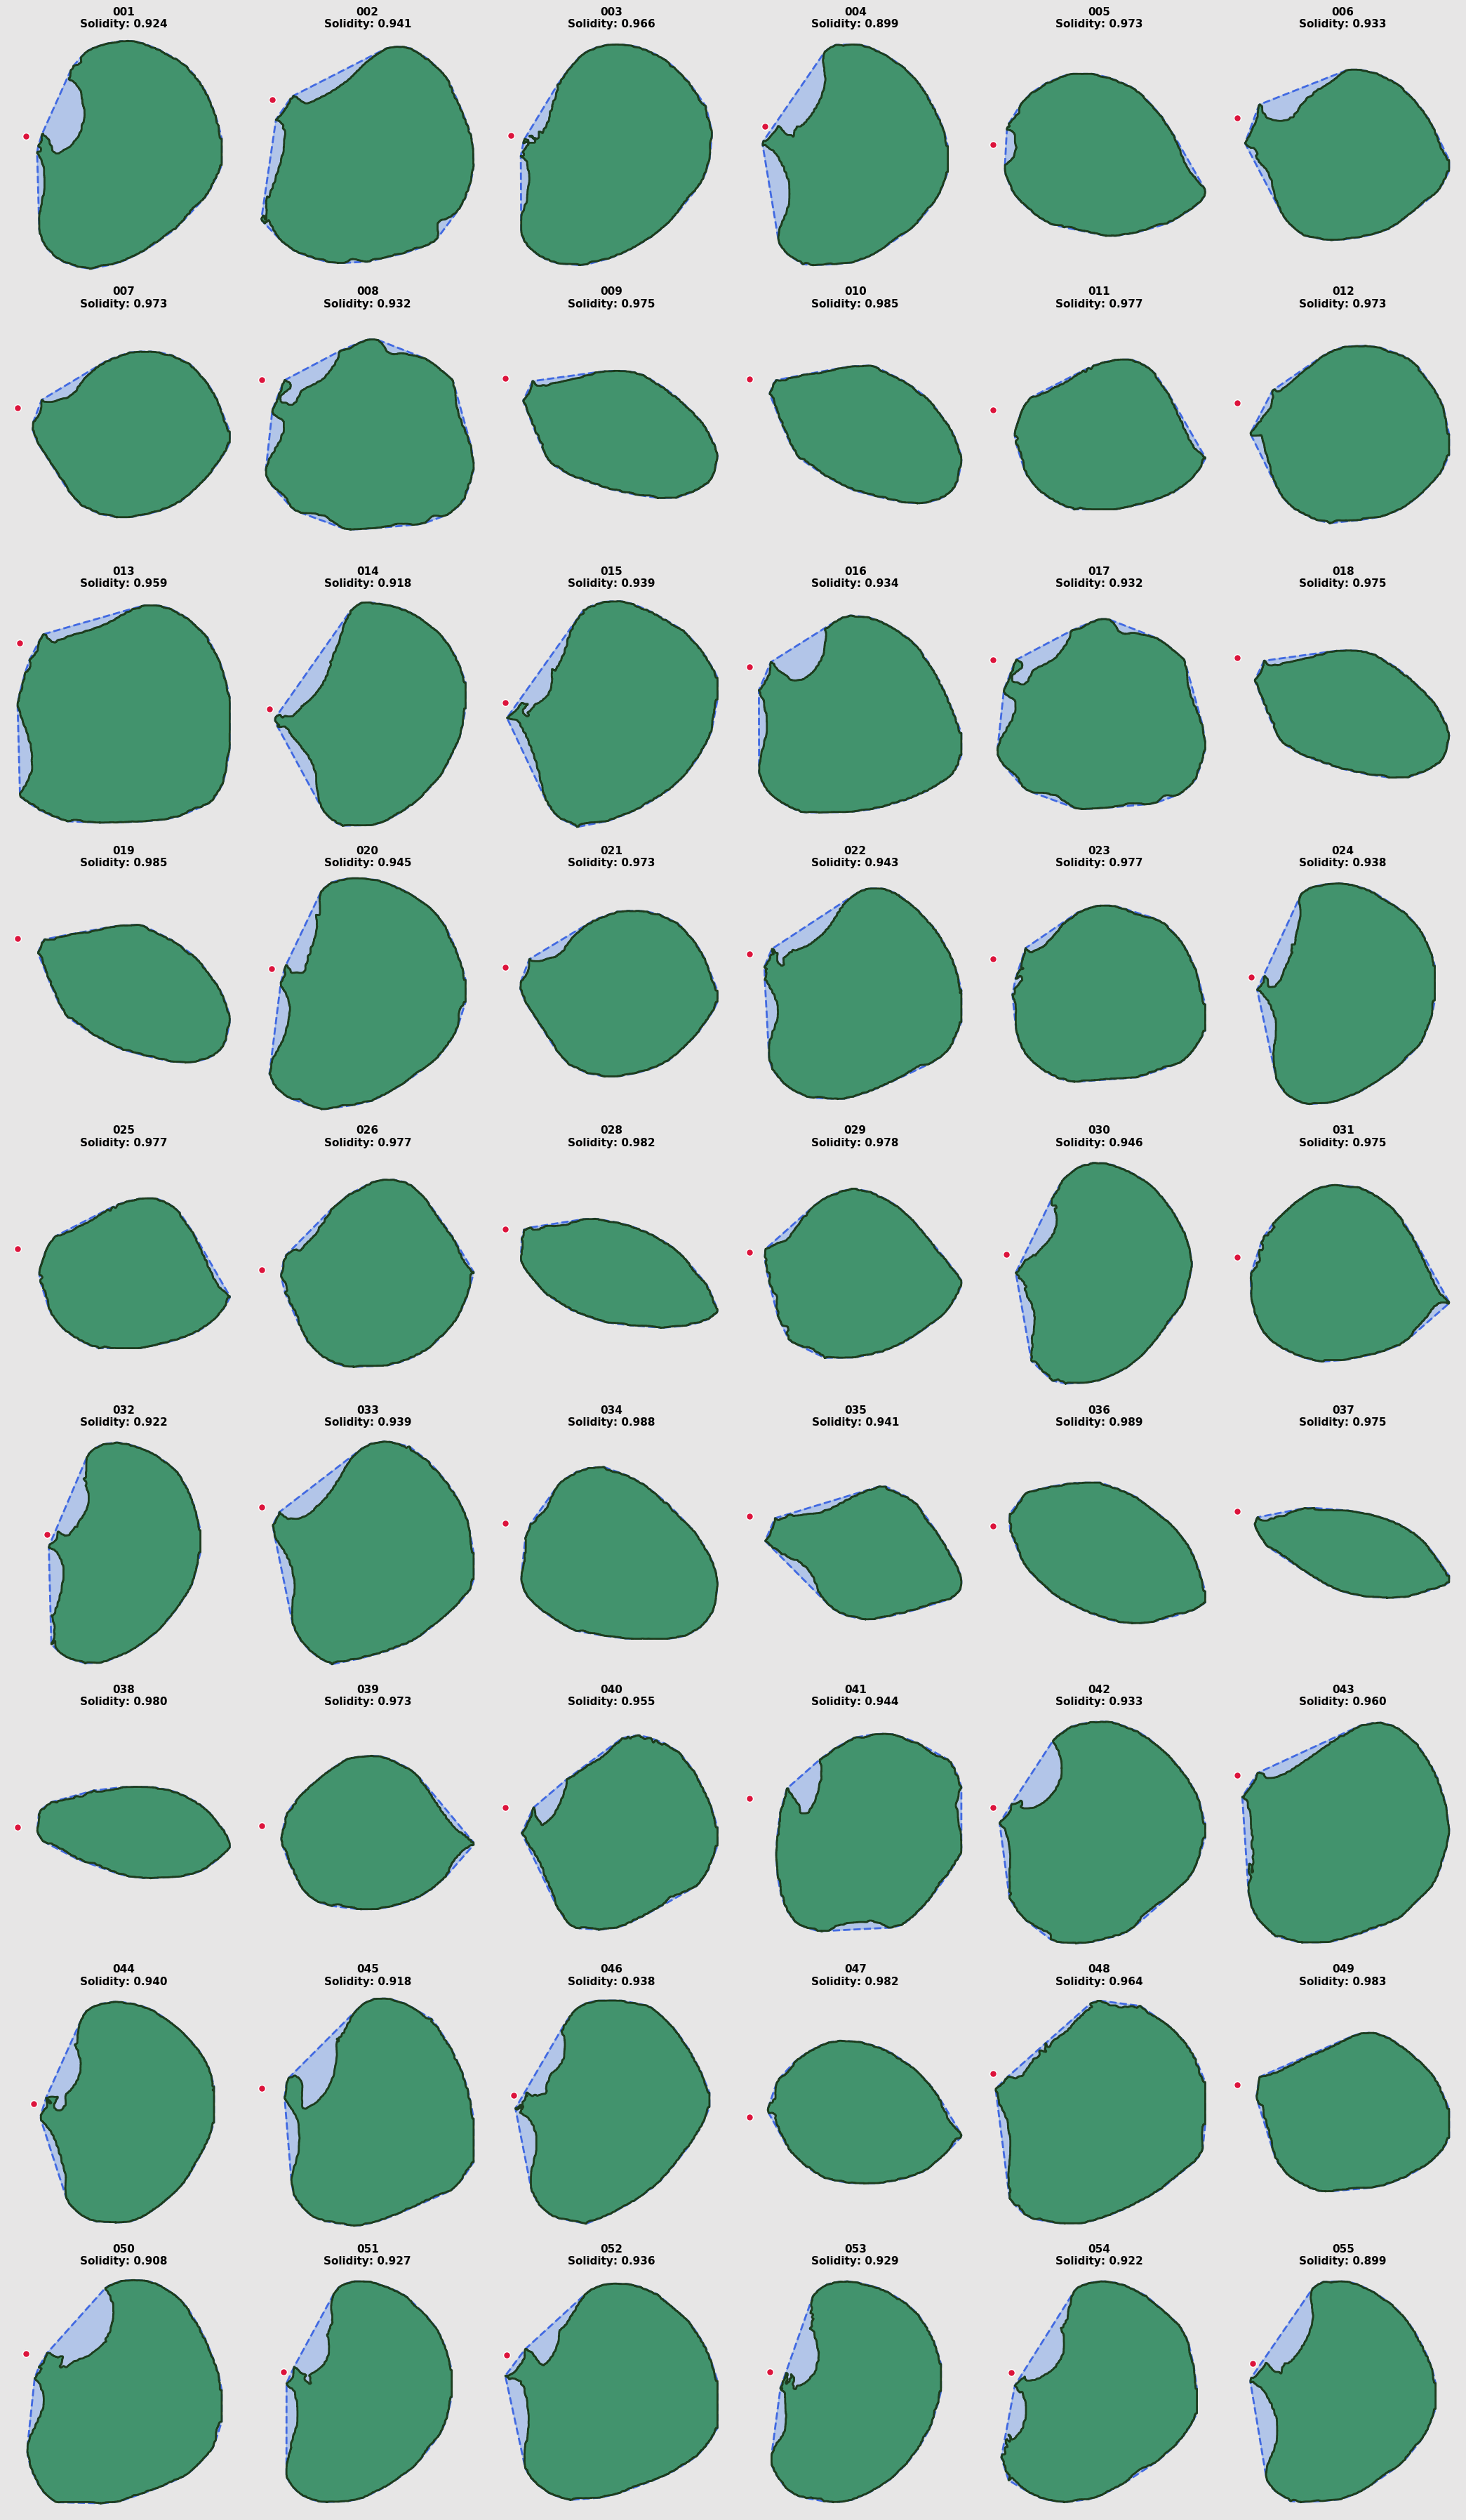

: 

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

# ==========================================
# 幾何特徵視覺化腳本 (Solidity 凸包比)
# ==========================================
def plot_solidity_features(binary_mask, origin_point, ax, label_name):
    # 尋找乾淨的輪廓
    kernel = np.ones((5, 5), np.uint8)
    clean_mask = cv2.morphologyEx(binary_mask, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if not contours: 
        ax.text(0.5, 0.5, "No Contour", ha='center', va='center')
        ax.axis('off')
        return
        
    cnt = max(contours, key=cv2.contourArea)
    
    # 🌟 計算實際面積與凸包 (Convex Hull)
    area = cv2.contourArea(cnt)
    hull = cv2.convexHull(cnt)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    # --- 開始繪圖 ---
    ax.set_facecolor('#E7E6E6')
    
    # 1. 繪製凸包 Convex Hull (分母)
    # 用淺藍色半透明填滿，並畫上虛線外框，代表花瓣理應佔據的「極限外框」
    hull_pts = np.vstack([hull[:, 0, :], hull[0, 0, :]])
    ax.fill(hull_pts[:, 0], hull_pts[:, 1], color='cornflowerblue', alpha=0.4, zorder=1)
    ax.plot(hull_pts[:, 0], hull_pts[:, 1], color='royalblue', linewidth=2, linestyle='--', zorder=2)
    
    # 2. 繪製實際輪廓 Actual Area (分子)
    # 用深綠色半透明疊加填滿，並畫上實線外框
    cnt_pts = np.vstack([cnt[:, 0, :], cnt[0, 0, :]])
    ax.fill(cnt_pts[:, 0], cnt_pts[:, 1], color='seagreen', alpha=0.85, zorder=3)
    ax.plot(cnt_pts[:, 0], cnt_pts[:, 1], color='#1E3D1E', linewidth=2, zorder=4)
    
    # 3. 依然標示生物學基部 (Column) 作為視覺參考點
    ax.scatter(origin_point[0], origin_point[1], color='crimson', s=50, zorder=5, edgecolors='white')

    # 顯示計算結果
    ax.set_title(f"{label_name}\nSolidity: {solidity:.3f}", fontsize=11, fontweight='bold')
    ax.axis('equal')
    ax.axis('off')

# ==========================================
# 批次生成網格視覺化
# ==========================================
print("[*] 正在繪製所有花瓣的 Solidity 視覺化...")

num_flowers = len(valid_filenames)
cols = 6  
rows = math.ceil(num_flowers / cols)

bg_color = '#E7E6E6'
fig_viz, axes_viz = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 4))
fig_viz.set_facecolor(bg_color)
axes_flat = axes_viz.flatten()

# 巡迴每一張有效影像繪圖
for idx, label in enumerate(valid_filenames):
    
    mask_path = os.path.join(mask_dir, f"{label}.png")
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    ax = axes_flat[idx]
    
    if mask is None: 
        ax.axis('off')
        continue
        
    # 補上 Padding
    mask = cv2.copyMakeBorder(mask, padding, padding, padding, padding, cv2.BORDER_CONSTANT, value=0)
    
    mask_c1 = np.where(mask == base_class_id, 255, 0).astype(np.uint8)
    M_c1 = cv2.moments(mask_c1)
    
    if M_c1["m00"] == 0: 
        ax.axis('off')
        continue
        
    column_centroid = np.array([int(M_c1["m10"]/M_c1["m00"]), int(M_c1["m01"]/M_c1["m00"])])
    
    mask_c7 = np.where(mask == target_class_id, 255, 0).astype(np.uint8)
    plot_solidity_features(mask_c7, column_centroid, ax, label)

# 隱藏多餘的空白子圖
for i in range(num_flowers, len(axes_flat)):
    axes_flat[i].axis('off')
    axes_flat[i].set_facecolor(bg_color)

plt.tight_layout()
plt.show()
